<>:227: SyntaxWarning: invalid escape sequence '\G'
<>:227: SyntaxWarning: invalid escape sequence '\G'
C:\Users\franc\AppData\Local\Temp\ipykernel_37740\1651592566.py:227: SyntaxWarning: invalid escape sequence '\G'
  cartella_grafici = os.path.join(cartella, "Grafici\Grafici_Generici")


Caricamento dati in corso...
Generazione grafici Y Pre-Correction...
Generazione grafici Y Post-Correction...
Generazione grafici X Pre-Correction...
Generazione grafici X Post-Correction...
Generazione grafici Aree...
Esportazione file PDF in corso...
Tutti i grafici singoli sono stati generati ed esportati con successo!


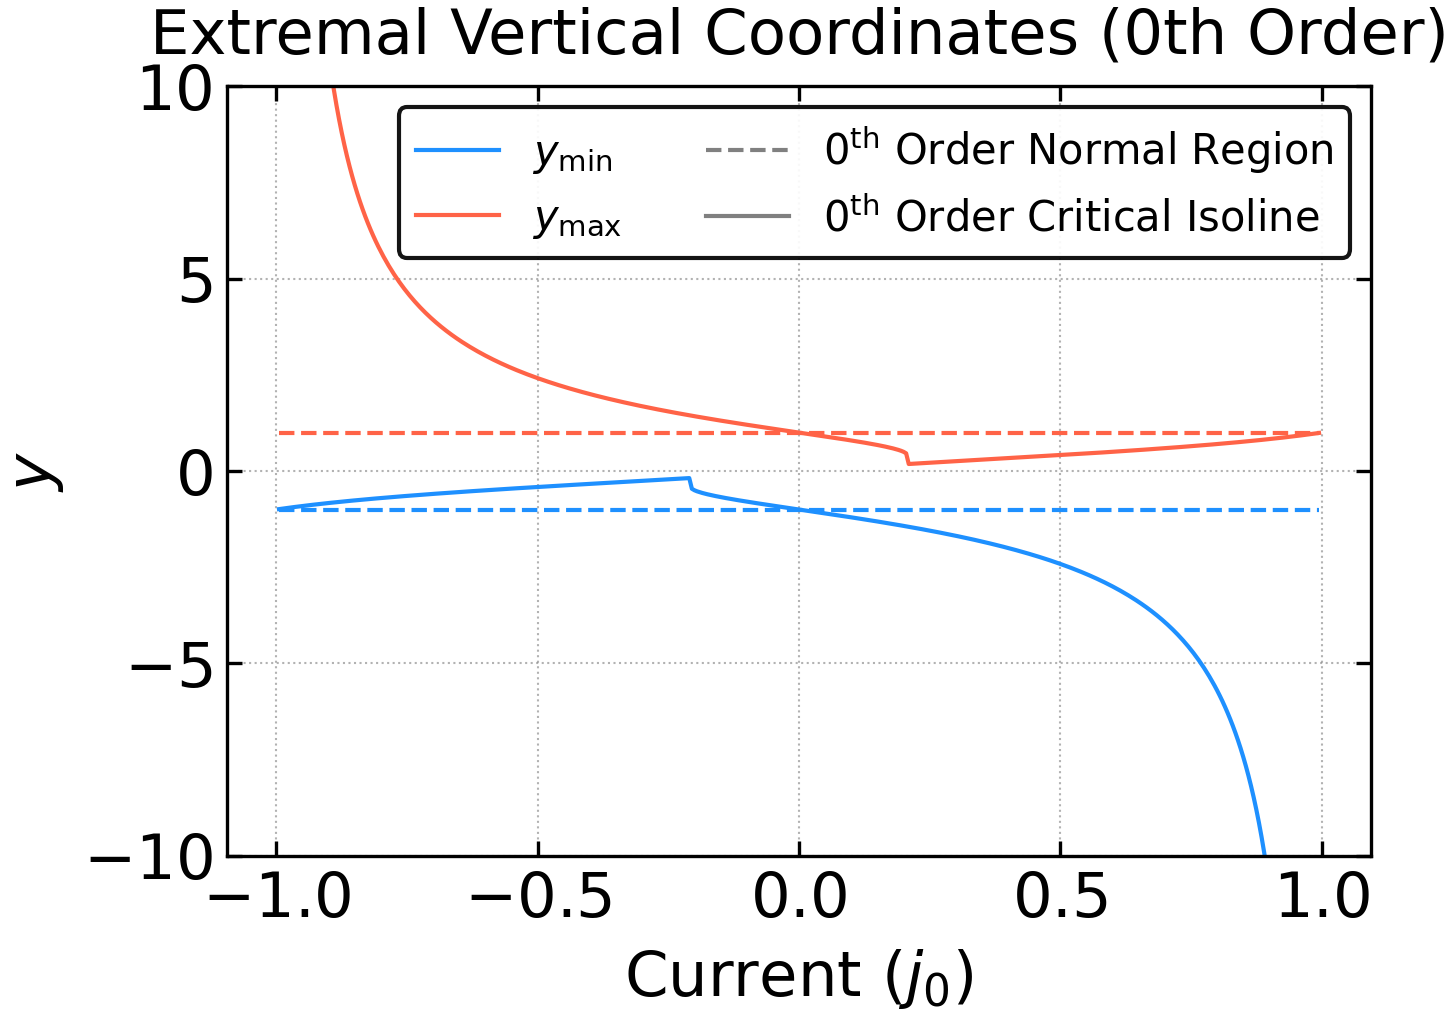

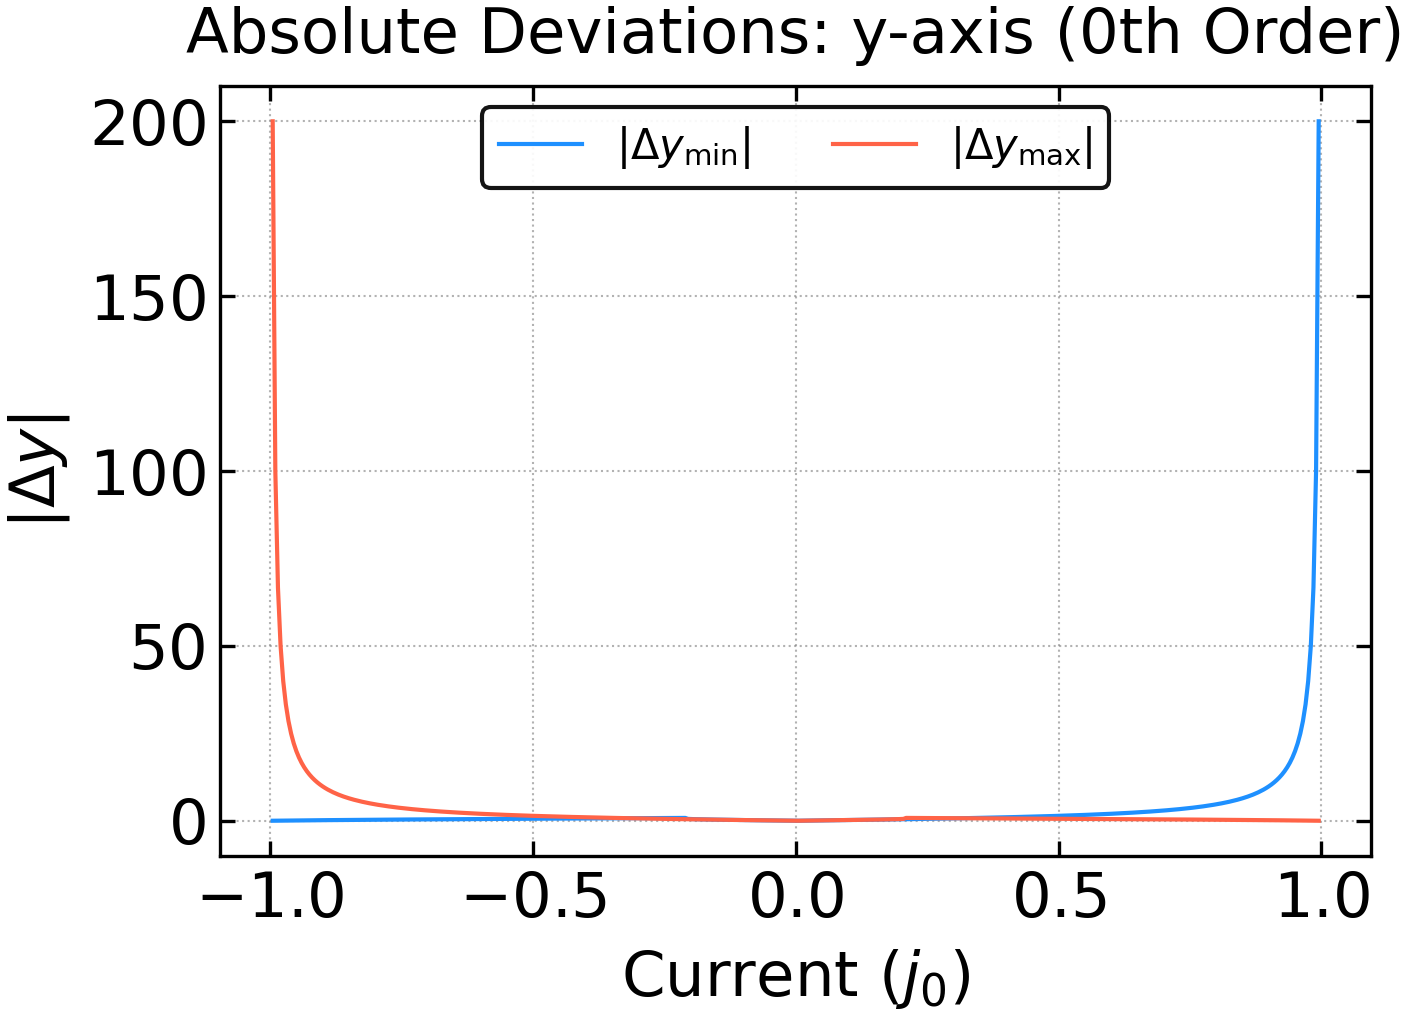

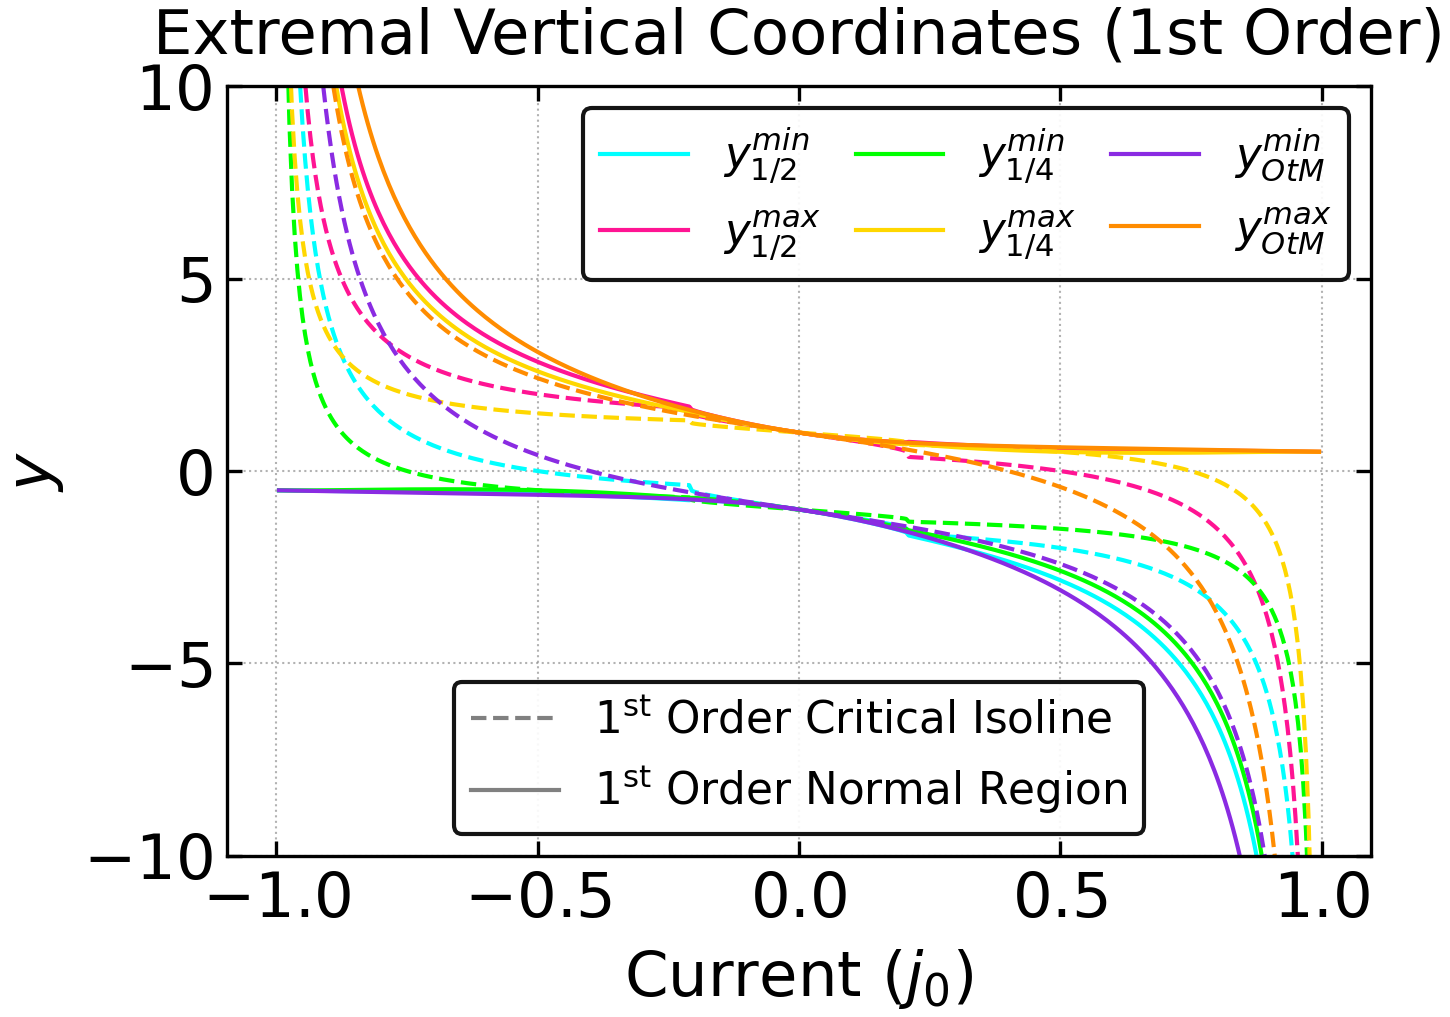

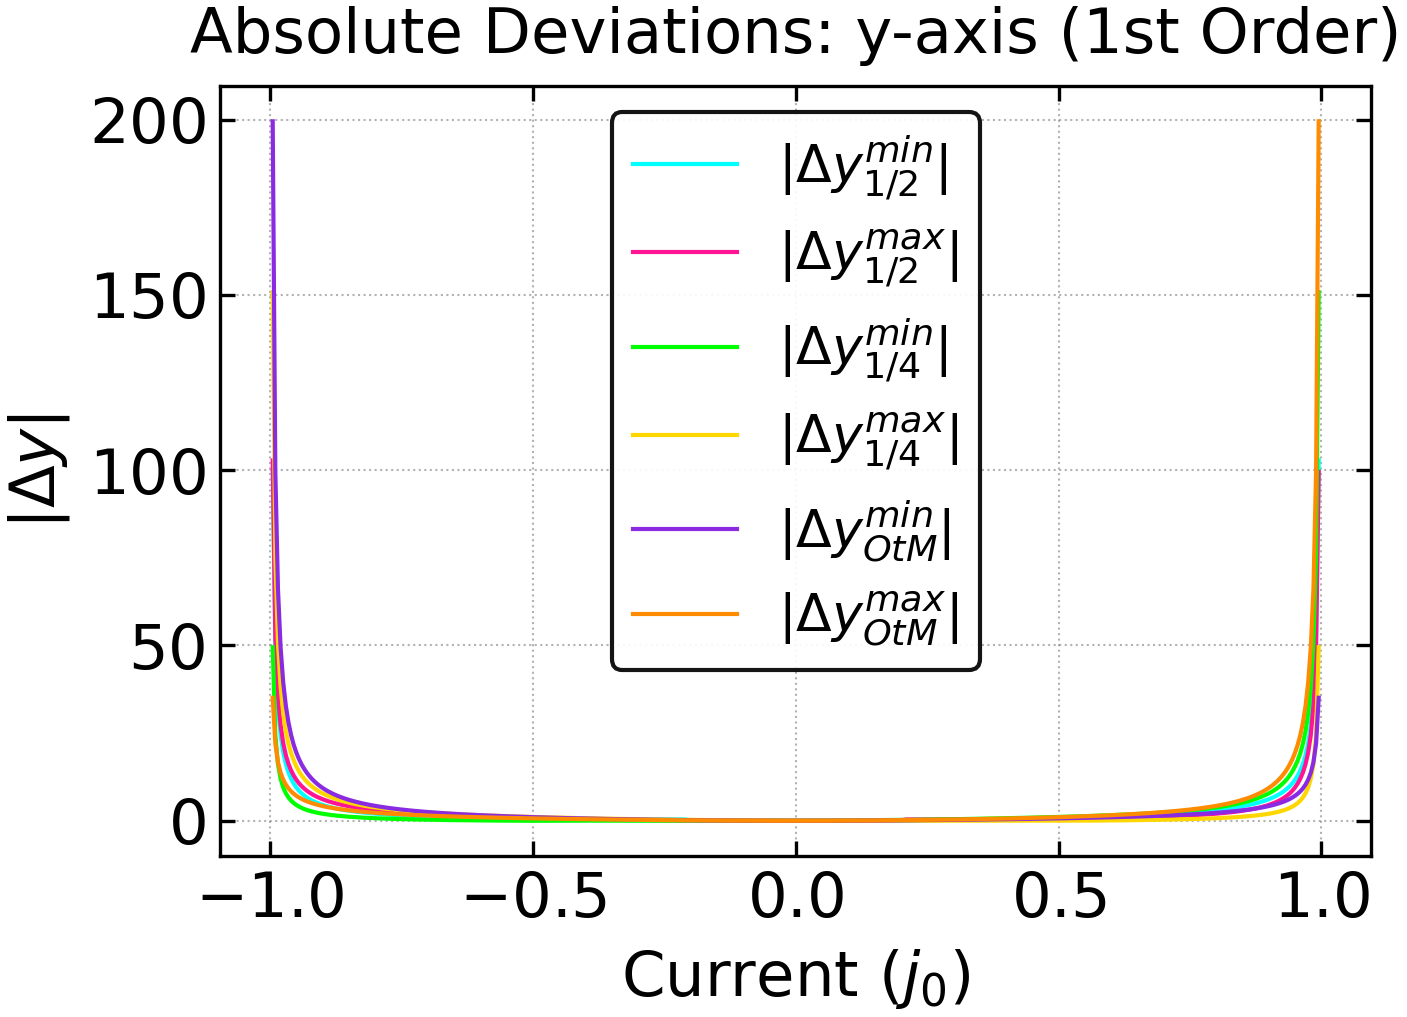

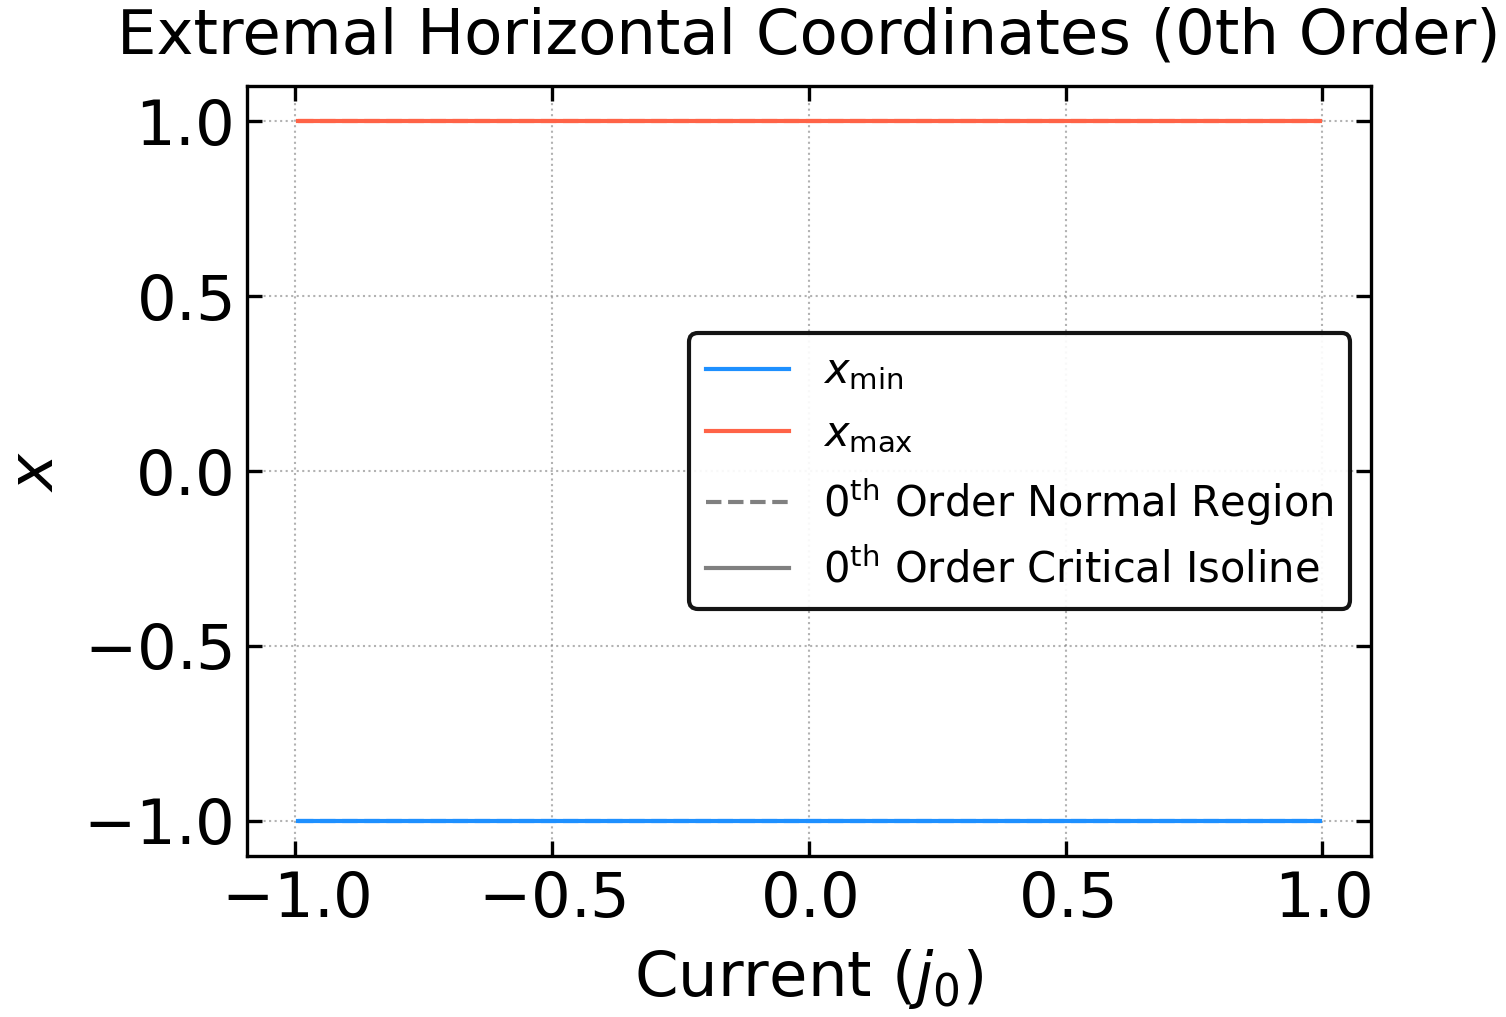

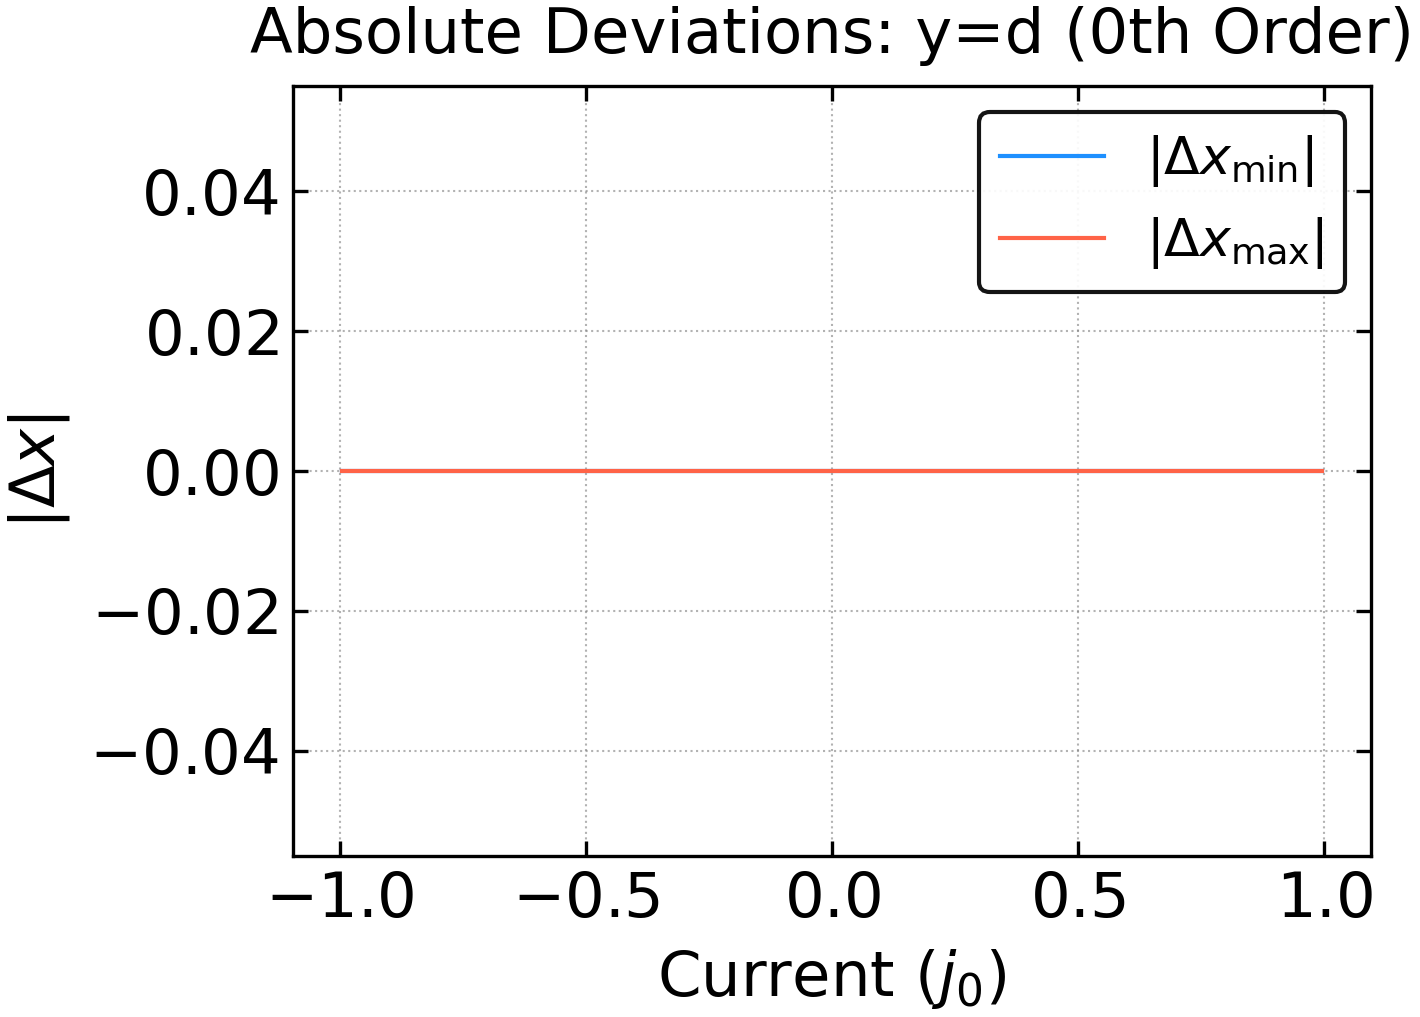

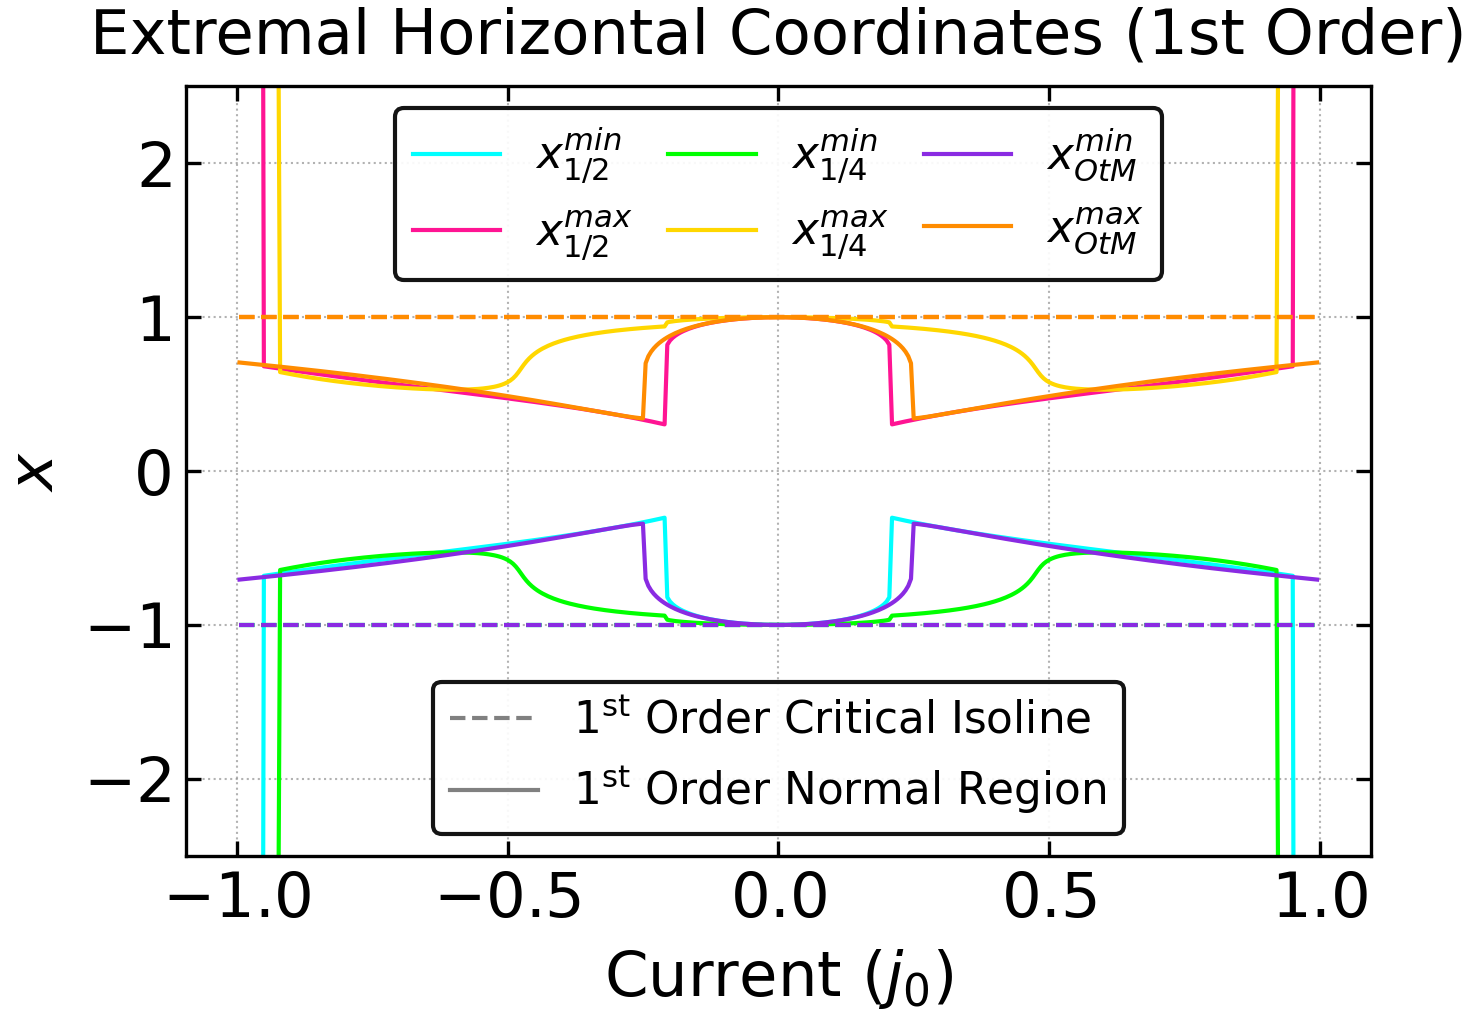

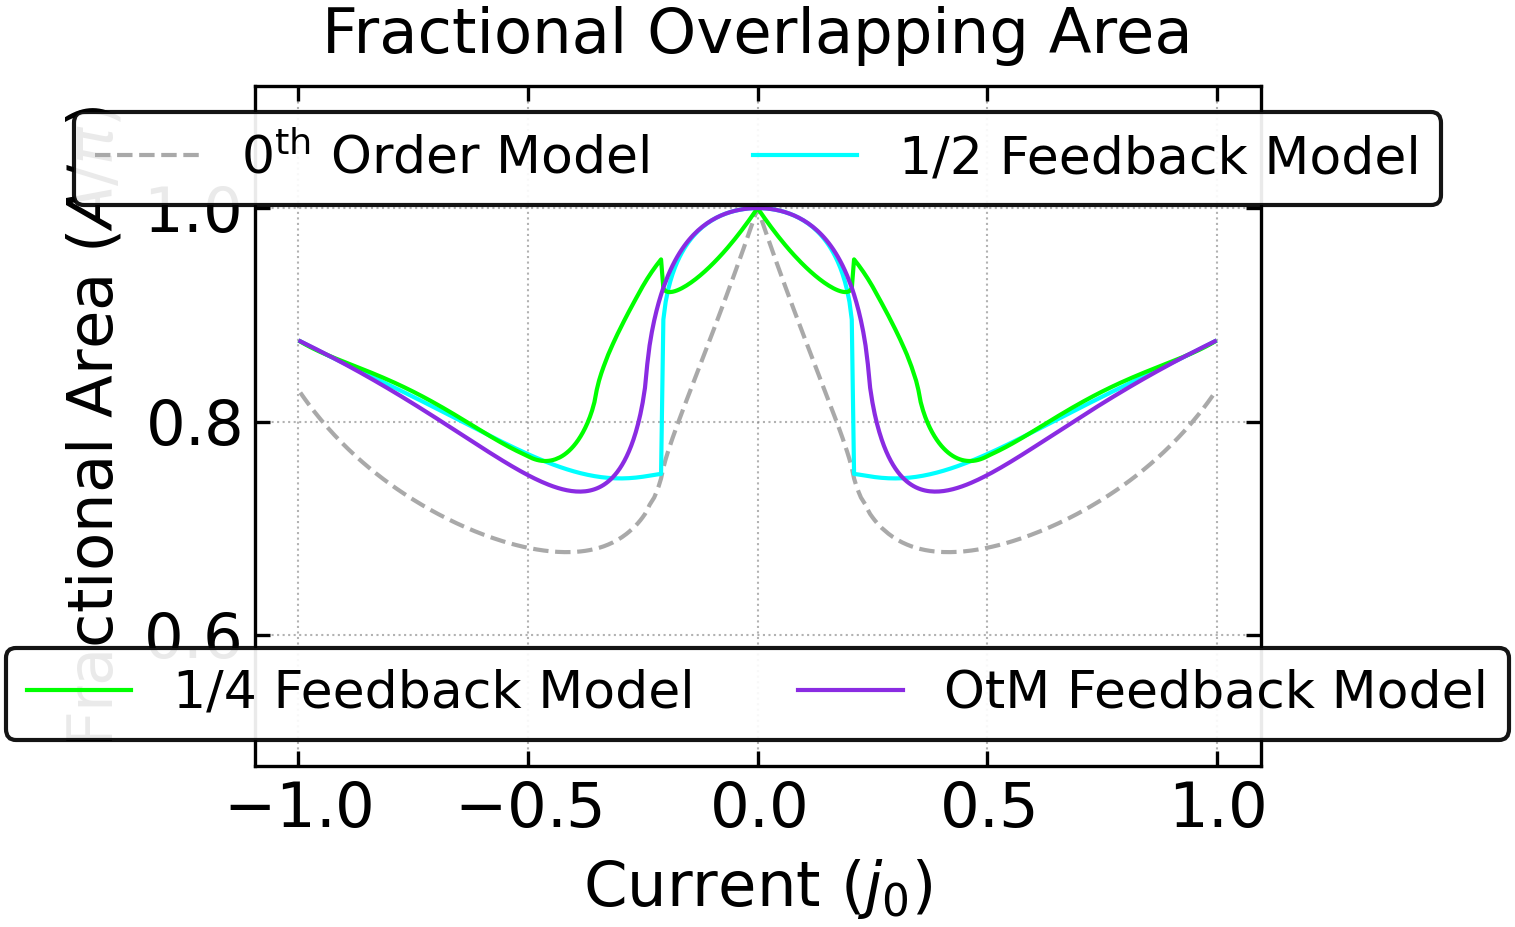

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os

# ================= IMPOSTAZIONI GLOBALI (STILE TESI LATEX) =================
# 1. Define the physical size of your target LaTeX space
# Width of ONE side-by-side image (~0.48 * 5.5 inches)
fig_width = 2.6  
fig_height = 2.2 # Adjust this to change the aspect ratio

plt.rcParams.update({
    "text.usetex": False,                 
    "mathtext.fontset": "dejavusans",             
    "font.family": "sans-serif",               
    "font.sans-serif": ["DejaVu Sans", "Arial"],
    "axes.formatter.use_mathtext": True,  
    
    # --- The Crucial Sizing Parameters ---
    "figure.figsize": (fig_width, fig_height), 
    "font.size": 15,       
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "legend.fontsize": 12.5,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    # -------------------------------------
    
    "axes.linewidth": 0.8,                
    "lines.linewidth": 1,               
    "xtick.major.width": 0.8,             
    "ytick.major.width": 0.8,             
    "xtick.direction": "in",              
    "ytick.direction": "in",
    "xtick.top": True,                    
    "ytick.right": True,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.framealpha": 0.92,
    "legend.edgecolor": "black",              
    "figure.dpi": 300,                    
    "savefig.bbox": "tight",              
    "savefig.pad_inches": 0.02 
})

# ================= CARICAMENTO DATI =================
cartella = "."
percorso_json = os.path.join(cartella, "DatiSingoloVortice.json")

print("Caricamento dati in corso...")
with open(percorso_json, "r") as f:
    dati = json.load(f)

def estrai_xy(chiave):
    arr = np.array(dati[chiave])
    return arr[:, 0], arr[:, 1]

# ================= FUNZIONE DI SUPPORTO PER I GRAFICI =================
def formatta_asse(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=8)
    ax.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6)

# ================= 1. GRAFICI Y PRE-CORRECTION =================
print("Generazione grafici Y Pre-Correction...")

# --- Grafico Coordinate Y ---
fig_y_pre_coord, ax = plt.subplots(figsize=(5.0, 3.8))
x, y = estrai_xy("circYMinPre"); ax.plot(x, y, color="dodgerblue", linestyle="--", linewidth=1)
x, y = estrai_xy("circYMaxPre"); ax.plot(x, y, color="tomato", linestyle="--", linewidth=1)
x, y = estrai_xy("pY1Pre");      ax.plot(x, y, color="dodgerblue", linestyle="-", label=r"$y_{\min}$")
x, y = estrai_xy("pY4Pre");      ax.plot(x, y, color="tomato", linestyle="-", label=r"$y_{\max}$")

ax.plot([], [], color="gray", linestyle="--", label=r"$0^{\mathrm{th}}$ Order Normal Region")
ax.plot([], [], color="gray", linestyle="-", label=r"$0^{\mathrm{th}}$ Order Critical Isoline")

formatta_asse(ax, r"Current ($j_0$)", r"$y$", "Extremal Vertical Coordinates (0th Order)")
ax.set_ylim(-10, 10) # <-- Added ylim here
ax.legend(loc="best", frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", ncol=2, fontsize=10) 
fig_y_pre_coord.tight_layout()

# --- Grafico Deviazioni Y ---
fig_y_pre_diff, ax = plt.subplots(figsize=(5.0, 3.8))
x, y = estrai_xy("diffYMinPre"); ax.plot(x, y, color="dodgerblue", linestyle="-", label=r"$|\Delta y_{\min}|$")
x, y = estrai_xy("diffYMaxPre"); ax.plot(x, y, color="tomato", linestyle="-", label=r"$|\Delta y_{\max}|$")
formatta_asse(ax, r"Current ($j_0$)", r"$|\Delta y|$", "Absolute Deviations: y-axis (0th Order)")
ax.legend(loc="best", frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", ncol=2, fontsize=10)
fig_y_pre_diff.tight_layout()

# ================= 2. GRAFICI Y POST-CORRECTION =================
print("Generazione grafici Y Post-Correction...")
# --- Grafico Coordinate Y ---
fig_y_post_coord, ax = plt.subplots(figsize=(5.0, 3.8))
x, y = estrai_xy("circYMinPost2"); ax.plot(x, y, color="cyan", linestyle="--", linewidth=1)
x, y = estrai_xy("circYMaxPost2"); ax.plot(x, y, color="deeppink", linestyle="--", linewidth=1)
x, y = estrai_xy("pY1Post2");      l1_y, = ax.plot(x, y, color="cyan", linestyle="-", label=r"$y^{min}_{1/2}$")
x, y = estrai_xy("pY4Post2");      l2_y, = ax.plot(x, y, color="deeppink", linestyle="-", label=r"$y^{max}_{1/2}$")

x, y = estrai_xy("circYMinPost4"); ax.plot(x, y, color="lime", linestyle="--", linewidth=1)
x, y = estrai_xy("circYMaxPost4"); ax.plot(x, y, color="gold", linestyle="--", linewidth=1)
x, y = estrai_xy("pY1Post4");      l3_y, = ax.plot(x, y, color="lime", linestyle="-", label=r"$y^{min}_{1/4}$")
x, y = estrai_xy("pY4Post4");      l4_y, = ax.plot(x, y, color="gold", linestyle="-", label=r"$y^{max}_{1/4}$")

x, y = estrai_xy("circYMinPost1"); ax.plot(x, y, color="blueviolet", linestyle="--", linewidth=1)
x, y = estrai_xy("circYMaxPost1"); ax.plot(x, y, color="darkorange", linestyle="--", linewidth=1)
x, y = estrai_xy("pY1Post1");      l5_y, = ax.plot(x, y, color="blueviolet", linestyle="-", label=r"$y^{min}_{OtM}$")
x, y = estrai_xy("pY4Post1");      l6_y, = ax.plot(x, y, color="darkorange", linestyle="-", label=r"$y^{max}_{OtM}$")

l7_y, = ax.plot([], [], color="gray", linestyle="--", label=r"$1^{\mathrm{st}}$ Order Critical Isoline")
l8_y, = ax.plot([], [], color="gray", linestyle="-", label=r"$1^{\mathrm{st}}$ Order Normal Region")

formatta_asse(ax, r"Current ($j_0$)", r"$y$", "Extremal Vertical Coordinates (1st Order)")
ax.set_ylim(-10, 10) 

# Split the legend: 6 models at the top (4 columns), 2 core boundaries at the bottom
leg_top_y = ax.legend(handles=[l1_y, l2_y, l3_y, l4_y, l5_y, l6_y], loc="upper right", ncol=3, fontsize=10.5, columnspacing=0.8, frameon=True, facecolor="white", framealpha=0.92, edgecolor="black")
ax.add_artist(leg_top_y)
ax.legend(handles=[l7_y, l8_y], loc="lower center", ncol=1, fontsize=10.5, frameon=True, facecolor="white", framealpha=0.92, edgecolor="black")

fig_y_post_coord.tight_layout()

# --- Grafico Deviazioni Y ---
fig_y_post_diff, ax = plt.subplots(figsize=(5.0, 3.8))
x, y = estrai_xy("diffYMinPost2"); ax.plot(x, y, color="cyan", linestyle="-", label=r"$|\Delta y^{min}_{1/2}|$")
x, y = estrai_xy("diffYMaxPost2"); ax.plot(x, y, color="deeppink", linestyle="-", label=r"$|\Delta y^{max}_{1/2}|$")
x, y = estrai_xy("diffYMinPost4"); ax.plot(x, y, color="lime", linestyle="-", label=r"$|\Delta y^{min}_{1/4}|$")
x, y = estrai_xy("diffYMaxPost4"); ax.plot(x, y, color="gold", linestyle="-", label=r"$|\Delta y^{max}_{1/4}|$")
x, y = estrai_xy("diffYMinPost1"); ax.plot(x, y, color="blueviolet", linestyle="-", label=r"$|\Delta y^{min}_{OtM}|$")
x, y = estrai_xy("diffYMaxPost1"); ax.plot(x, y, color="darkorange", linestyle="-", label=r"$|\Delta y^{max}_{OtM}|$")
formatta_asse(ax, r"Current ($j_0$)", r"$|\Delta y|$", "Absolute Deviations: y-axis (1st Order)")
ax.legend(loc="best", frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", ncol=1, fontsize=12.5)
fig_y_post_diff.tight_layout()

# ================= 3. GRAFICI X PRE-CORRECTION =================
print("Generazione grafici X Pre-Correction...")

# --- Grafico Coordinate X ---
fig_x_pre_coord, ax = plt.subplots(figsize=(5.0, 3.8))
x, y = estrai_xy("circXMinPre"); ax.plot(x, y, color="dodgerblue", linestyle="--", linewidth=1)
x, y = estrai_xy("circXMaxPre"); ax.plot(x, y, color="tomato", linestyle="--", linewidth=1)
x, y = estrai_xy("pX1Pre");      ax.plot(x, y, color="dodgerblue", linestyle="-", label=r"$x_{\min}$")
x, y = estrai_xy("pX4Pre");      ax.plot(x, y, color="tomato", linestyle="-", label=r"$x_{\max}$")

ax.plot([], [], color="gray", linestyle="--", label=r"$0^{\mathrm{th}}$ Order Normal Region")
ax.plot([], [], color="gray", linestyle="-", label=r"$0^{\mathrm{th}}$ Order Critical Isoline")

formatta_asse(ax, r"Current ($j_0$)", r"$x$", "Extremal Horizontal Coordinates (0th Order)")
ax.legend(loc="best", frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", ncol=1, fontsize=10)
fig_x_pre_coord.tight_layout()

# --- Grafico Deviazioni X ---
fig_x_pre_diff, ax = plt.subplots(figsize=(5.0, 3.8))
x, y = estrai_xy("diffXMinPre"); ax.plot(x, y, color="dodgerblue", linestyle="-", label=r"$|\Delta x_{\min}|$")
x, y = estrai_xy("diffXMaxPre"); ax.plot(x, y, color="tomato", linestyle="-", label=r"$|\Delta x_{\max}|$")
formatta_asse(ax, r"Current ($j_0$)", r"$|\Delta x|$", "Absolute Deviations: y=d (0th Order)")
ax.legend(loc="best", frameon=True, facecolor="white", framealpha=0.92, edgecolor="black")
fig_x_pre_diff.tight_layout()

# ================= 4. GRAFICI X POST-CORRECTION =================
print("Generazione grafici X Post-Correction...")

# --- Grafico Coordinate X ---
fig_x_post_coord, ax = plt.subplots(figsize=(5.0, 3.8))

x, y = estrai_xy("circXMinPost2"); ax.plot(x, y, color="cyan", linestyle="--", linewidth=1)
x, y = estrai_xy("circXMaxPost2"); ax.plot(x, y, color="deeppink", linestyle="--", linewidth=1)
x, y = estrai_xy("pX1Post2");      l1, = ax.plot(x, y, color="cyan", linestyle="-", label=r"$x^{min}_{1/2}$")
x, y = estrai_xy("pX4Post2");      l2, = ax.plot(x, y, color="deeppink", linestyle="-", label=r"$x^{max}_{1/2}$")

x, y = estrai_xy("circXMinPost4"); ax.plot(x, y, color="lime", linestyle="--", linewidth=1)
x, y = estrai_xy("circXMaxPost4"); ax.plot(x, y, color="gold", linestyle="--", linewidth=1)
x, y = estrai_xy("pX1Post4");      l3, = ax.plot(x, y, color="lime", linestyle="-", label=r"$x^{min}_{1/4}$")
x, y = estrai_xy("pX4Post4");      l4, = ax.plot(x, y, color="gold", linestyle="-", label=r"$x^{max}_{1/4}$")

x, y = estrai_xy("circXMinPost1"); ax.plot(x, y, color="blueviolet", linestyle="--", linewidth=1)
x, y = estrai_xy("circXMaxPost1"); ax.plot(x, y, color="darkorange", linestyle="--", linewidth=1)
x, y = estrai_xy("pX1Post1");      l5, = ax.plot(x, y, color="blueviolet", linestyle="-", label=r"$x^{min}_{OtM}$")
x, y = estrai_xy("pX4Post1");      l6, = ax.plot(x, y, color="darkorange", linestyle="-", label=r"$x^{max}_{OtM}$")

l7, = ax.plot([], [], color="gray", linestyle="--", label=r"$1^{\mathrm{st}}$ Order Critical Isoline")
l8, = ax.plot([], [], color="gray", linestyle="-", label=r"$1^{\mathrm{st}}$ Order Normal Region")

formatta_asse(ax, r"Current ($j_0$)", r"$x$", "Extremal Horizontal Coordinates (1st Order)")
ax.set_ylim(-2.5, 2.5) 

# Split the legend: models at the top (4 columns), core boundaries at the bottom
leg_top = ax.legend(handles=[l1, l2, l3, l4, l5, l6], loc="upper center", ncol=3, fontsize=10.5, columnspacing=0.8, frameon=True, facecolor="white", framealpha=0.92, edgecolor="black")
ax.add_artist(leg_top) 
ax.legend(handles=[l7, l8], loc="lower center", ncol=1, fontsize=10.5, frameon=True, facecolor="white", framealpha=0.92, edgecolor="black")

fig_x_post_coord.tight_layout()

# ================= 5. PANNELLO AREE SOVRAPPOSTE =================
def estrai_xy_clean(chiave):
    arr = np.array(dati[chiave])
    mask = arr[:, 1] > 1e-5
    return arr[mask, 0], arr[mask, 1]

print("Generazione grafici Aree...")
fig_aree, ax = plt.subplots(figsize=(5.0, 3.5))

# Scaling factor for a single hole (Area = pi * R^2 = pi)
scale_factor = 1 / np.pi 

x, y = estrai_xy_clean("areaBaseList");  h_base, = ax.plot(x, y * scale_factor, color="darkgray",   linestyle="--", label=r"$0^{\mathrm{th}}$ Order Model")
x, y = estrai_xy_clean("areaPost2List"); h_p2, = ax.plot(x, y * scale_factor, color="cyan",       linestyle="-",  label="1/2 Feedback Model")
x, y = estrai_xy_clean("areaPost4List"); h_p4, = ax.plot(x, y * scale_factor, color="lime",       linestyle="-",  label="1/4 Feedback Model")
x, y = estrai_xy_clean("areaPost1List"); h_p1, = ax.plot(x, y * scale_factor, color="blueviolet", linestyle="-",  label="OtM Feedback Model")

# Updated labels and title for the fractional representation
formatta_asse(ax, r"Current ($j_0$)", r"Fractional Area ($A/\pi$)", r"Fractional Overlapping Area")

# Updated y-limits scaled proportionally to match the previous visual framing
ax.set_ylim(1.5 * scale_factor, 3.5 * scale_factor)

# Split the legend: First two sentences on top, last two on the bottom
leg_area_top = ax.legend(handles=[h_base, h_p2], loc="upper center", fontsize=12.5, ncol=2, frameon=True, facecolor="white", framealpha=0.92, edgecolor="black")
ax.add_artist(leg_area_top)
ax.legend(handles=[h_p4, h_p1], loc="lower center", fontsize=12.5, ncol=2, frameon=True, facecolor="white", framealpha=0.92, edgecolor="black")

fig_aree.tight_layout()

# ================= ESPORTAZIONE PDF =================
print("Esportazione file PDF in corso...")
cartella_grafici = os.path.join(cartella, "Grafici\Grafici_Generici")
os.makedirs(cartella_grafici, exist_ok=True)

fig_y_pre_coord.savefig(os.path.join(cartella_grafici, "maxminY_pre_coords.pdf"), dpi=300)
fig_y_pre_diff.savefig(os.path.join(cartella_grafici, "maxminY_pre_diff.pdf"), dpi=300)

fig_y_post_coord.savefig(os.path.join(cartella_grafici, "maxminY_post_coords.pdf"), dpi=300)
fig_y_post_diff.savefig(os.path.join(cartella_grafici, "maxminY_post_diff.pdf"), dpi=300)

fig_x_pre_coord.savefig(os.path.join(cartella_grafici, "maxminX_traslato_pre_coords.pdf"), dpi=300)
fig_x_pre_diff.savefig(os.path.join(cartella_grafici, "maxminX_traslato_pre_diff.pdf"), dpi=300)

fig_x_post_coord.savefig(os.path.join(cartella_grafici, "maxminX_traslato_post_coords.pdf"), dpi=300)
fig_x_post_diff.savefig(os.path.join(cartella_grafici, "maxminX_traslato_post_diff.pdf"), dpi=300)

fig_aree.savefig(os.path.join(cartella_grafici, "aree_sovrapposte.pdf"), dpi=300)

print("Tutti i grafici singoli sono stati generati ed esportati con successo!")
plt.show()

<>:134: SyntaxWarning: invalid escape sequence '\G'
<>:134: SyntaxWarning: invalid escape sequence '\G'
C:\Users\franc\AppData\Local\Temp\ipykernel_37740\389145207.py:134: SyntaxWarning: invalid escape sequence '\G'
  cartella_grafici = os.path.join(cartella, "Grafici\Grafici_Particolari")


Loading Line data from JSON...
Generating Line Plot with Inset Zoom...
Exporting PDF file...
Grafico salvato con successo come Line_Lines_Zoom_Right_HighContrast.pdf!


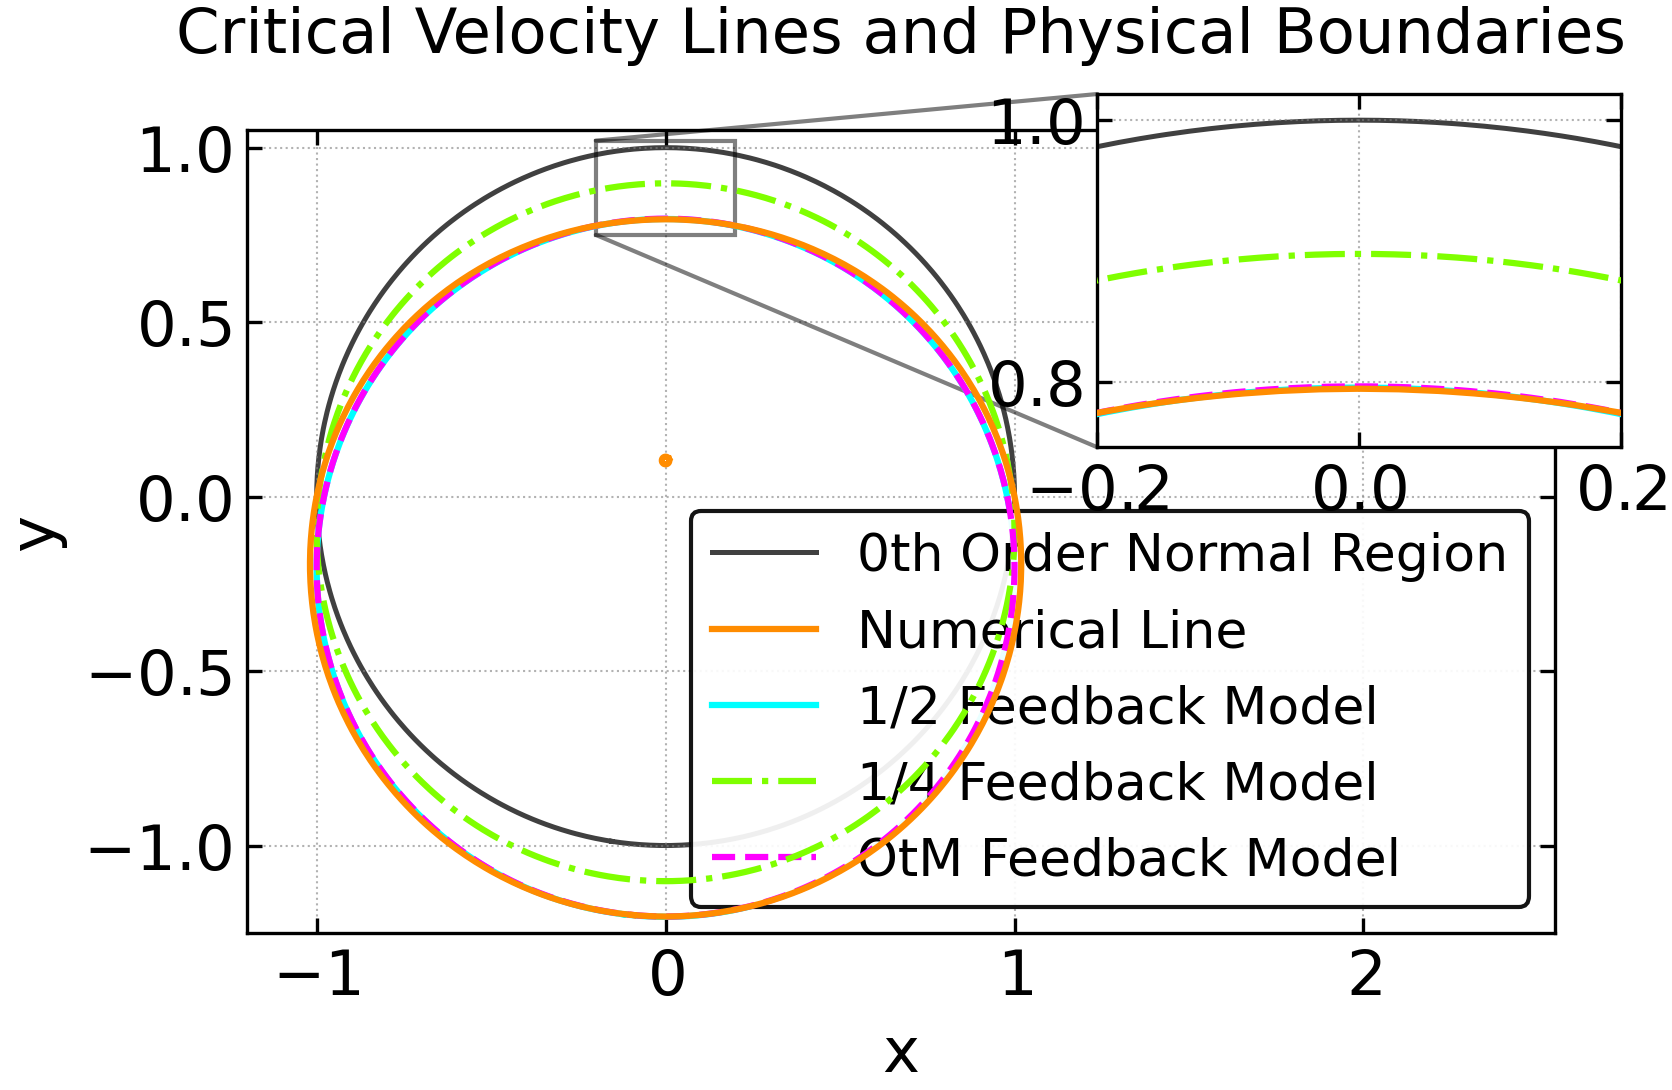

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os

# ================= IMPOSTAZIONI GLOBALI (STILE TESI LATEX) =================
# Width of ONE side-by-side image (~0.48 * 5.5 inches)
fig_width = 2.6  
fig_height = 2.2 # Adjust this to change the aspect ratio

plt.rcParams.update({
    "text.usetex": False,                 
    "mathtext.fontset": "dejavusans",             
    "font.family": "sans-serif",               
    "font.sans-serif": ["DejaVu Sans", "Arial"],
    "axes.formatter.use_mathtext": True,  
    
    # --- The Crucial Sizing Parameters ---
    "figure.figsize": (fig_width, fig_height), # Forces output to exact LaTeX size
    "font.size": 15,       # sapthesis default base font size is usually 11pt
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "legend.fontsize": 12.5,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    # -------------------------------------
    
    "axes.linewidth": 0.8,                
    "lines.linewidth": 1.0,  # Ridotto a 1.0 come richiesto             
    "xtick.major.width": 0.8,             
    "ytick.major.width": 0.8,             
    "xtick.direction": "in",              
    "ytick.direction": "in",
    "xtick.top": True,                    
    "ytick.right": True,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.framealpha": 0.92,
    "legend.edgecolor": "black",              
    "figure.dpi": 300,       # Increased to 300 for crisp print quality               
    "savefig.bbox": "tight",              
    "savefig.pad_inches": 0.02 # Reduced slightly to prevent blank space issues 
})

# ================= DATA LOADING =================
cartella = "."
file_json = os.path.join(cartella, "dati_curve_livello.json")

print("Loading Line data from JSON...")
try:
    with open(file_json, "r") as f:
        dati = json.load(f)
except FileNotFoundError:
    print(f"Errore: Il file {file_json} non è stato trovato.")
    dati = {"curve": {}}

# ================= PLOT CONFIGURATION =================
print("Generating Line Plot with Inset Zoom...")
fig, ax = plt.subplots(figsize=(6.0, 6.0))

# Creazione dell'asse di zoom posizionato a x0 = 0.75
ax_ins = ax.inset_axes([0.65, 0.60, 0.40, 0.45])

# ================= CURVE SELEZIONATE (VIVID & HIGH-CONTRAST) =================
config_curve = {
    # 1. Il buco fisso originario - Dark Gray for neutral background contrast
    "buco_originale": {"color": "#404040", "lw": 1.2, "ls": "-", "zorder": 1, "label": "0th Order Normal Region"},

    # 2. La curva di livello reale - Deep Orange (High contrast vs Cyan/Lime)
    "reale_numerica": {"color": "#FF8C00", "lw": 1.5, "ls": "-", "zorder": 10, "label": "Numerical Line"},
    
    # 3. Feedback /2 - Electric Cyan (Vibrant cool tone)
    "circonferenza_media": {"color": "#00FFFF", "lw": 1.5, "ls": "-", "zorder": 5, "label": "1/2 Feedback Model"},
    
    # 4. Feedback /4 - Bright Lime (High visibility green)
    "circonferenza_quarti": {"color": "#7FFF00", "lw": 1.5, "ls": "-.", "zorder": 6, "label": "1/4 Feedback Model"},
    
    # 5. Feedback OtB - Vivid Magenta (Distinct warm tone)
    "circonferenza_ymin": {"color": "#FF00FF", "lw": 1.5, "ls": "--", "zorder": 7, "label": "OtM Feedback Model"}
}

# ================= PLOTTING LOGIC =================
curve_data = dati.get("curve", {})

for nome_curva, stile in config_curve.items():
    if nome_curva in curve_data:
        segmenti = curve_data[nome_curva]
        
        for i, segmento in enumerate(segmenti):
            if not segmento:
                continue
                
            x = [punto[0] for punto in segmento]
            y = [punto[1] for punto in segmento]
            
            # Label only for the very first segment of each curve to avoid duplicates
            label = stile["label"] if i == 0 else ""
            
            # 1. Main Plot: Gets the label
            ax.plot(x, y, color=stile["color"], linewidth=stile["lw"], 
                    linestyle=stile["ls"], zorder=stile["zorder"], label=label)
            
            # 2. Inset Plot: No label provided here
            ax_ins.plot(x, y, color=stile["color"], linewidth=stile["lw"], 
                        linestyle=stile["ls"], zorder=stile["zorder"])

# ================= FORMATTING & AXES =================
ax.set_xlabel(r"x")
ax.set_ylabel(r"y")
ax.set_title("Critical Velocity Lines and Physical Boundaries", pad=10)

ax.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6, zorder=0)

# Limiti grafico principale: Esteso il limite destro da 1.9 a 2.5
ax.set_xlim(-1.2, 2.55) 
ax.set_ylim(-1.25, 1.05)
ax.set_aspect('equal')

# --- FORMATTAZIONE ZOOM ---
ax_ins.set_xlim(-0.2, 0.2)
ax_ins.set_ylim(0.75, 1.02)
ax_ins.set_aspect('equal')
ax_ins.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6, zorder=0)

ax.indicate_inset_zoom(ax_ins, edgecolor="black", alpha=0.5)

# --- POSIZIONAMENTO LEGENDA ---
ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", fontsize=12.5)

fig.tight_layout()

# ================= PDF EXPORT & DISPLAY =================
print("Exporting PDF file...")
cartella_grafici = os.path.join(cartella, "Grafici\Grafici_Particolari")
os.makedirs(cartella_grafici, exist_ok=True)

nome_salvataggio = "Line_Lines_Zoom_Right_HighContrast.pdf"
fig.savefig(os.path.join(cartella_grafici, nome_salvataggio), dpi=300, bbox_inches="tight")

print(f"Grafico salvato con successo come {nome_salvataggio}!")
plt.show()

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# ================= IMPOSTAZIONI GLOBALI (STILE TESI LATEX) =================
fig_width = 2.6  
fig_height = 2.2 

plt.rcParams.update({
    "text.usetex": False,                 
    "mathtext.fontset": "dejavusans",             
    "font.family": "sans-serif",               
    "font.sans-serif": ["DejaVu Sans", "Arial"],
    "axes.formatter.use_mathtext": True,  
    
    "figure.figsize": (fig_width, fig_height), 
    "font.size": 15,       
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "legend.fontsize": 12.5,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    
    "axes.linewidth": 0.8,                
    "lines.linewidth": 1.0,               
    "xtick.major.width": 0.8,             
    "ytick.major.width": 0.8,             
    "xtick.direction": "in",              
    "ytick.direction": "in",
    "xtick.top": True,                    
    "ytick.right": True,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.framealpha": 0.92,
    "legend.edgecolor": "black",              
    "figure.dpi": 300,                    
    "savefig.bbox": "tight",              
    "savefig.pad_inches": 0.02 
})

# ================= HELPER FUNCTIONS =================
def draw_obstacle(ax, d_val, label_text="Defect"):
    circle = patches.Circle((0, d_val), 1.0, edgecolor='black', 
                            facecolor=(1.0, 1.0, 1.0, 1), 
                            linewidth=1.0, linestyle='-', zorder=4, label=label_text)
    ax.add_patch(circle)

def plot_segments(ax, segments, style_dict, is_first_label_done):
    for segmento in segments:
        if not segmento:
            continue
        sx = [p[0] for p in segmento]
        sy = [p[1] for p in segmento]
        
        # Use "_nolegend_" to prevent duplicate empty entries in the legend
        label = style_dict["label"] if not is_first_label_done else "_nolegend_"
        
        ax.plot(sx, sy, color=style_dict["color"], linewidth=style_dict["lw"], 
                linestyle=style_dict["ls"], zorder=style_dict["zorder"], label=label)
        is_first_label_done = True
    return is_first_label_done

# ================= CONFIGURAZIONE CARTELLA =================
cartella = "."
cartella_grafici = os.path.join(cartella, "Grafici\\Grafici_Particolari")
os.makedirs(cartella_grafici, exist_ok=True)

cmap_custom = LinearSegmentedColormap.from_list(
    "BlueToRed", 
    ["midnightblue", "dodgerblue", "cyan", "gold", "red", "darkred"]
)
ticks_comuni = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2]

prefissi = [
    "nocorr_c0.1", 
    "corr_noappr_c0.1", 
    "corr_mean_c0.1", 
    "corr_min_c0.1", 
    "onlyvortex_c0.1", 
    "onlyhole_c0.1", 
    "onlydipole_c0.1", 
    "complete_c0.1",
    "crit_c0.21", 
    "corr_noappr_crit_c0.21", 
    "corr_mean_crit_c0.21", 
    "corr_min_crit_c0.21",
    "crit_c0.6", 
    "corr_noappr_crit_c0.6", 
    "corr_mean_crit_c0.6", 
    "corr_min_crit_c0.6",
    ]

suffisso = "_dati.json" 

# ================= CICLO PRINCIPALE =================
for prefisso in prefissi:
    if "onlyhole" in prefisso:
        defect_label = "Circular Defect"
        crit_label   = ""
    elif any(k in prefisso for k in ["corr_noappr", "corr_mean", "corr_min"]):
        defect_label = r"$1^{\mathrm{st}}$ Order Normal Region"
        crit_label = r"$1^{\mathrm{st}}$ Order Critical Isoline"
    elif "onlyvortex" in prefisso:
        defect_label = r"Vortex Core Region"
        crit_label   = r"Isoline |\textbf{v}|=1"
    else:
        defect_label = r"$0^{\mathrm{th}}$ Order Normal Region"
        crit_label   = r"$0^{\mathrm{th}}$ Order Critical Isoline"

    NOME_FILE_JSON = f"{prefisso}{suffisso}"
    file_json = os.path.join(cartella, NOME_FILE_JSON)

    print(f"\n[{prefisso}] Loading data from {NOME_FILE_JSON}...")
    try:
        with open(file_json, "r") as f:
            dati = json.load(f)
    except FileNotFoundError:
        print(f"[{prefisso}] Errore: Il file {file_json} non è stato trovato. Salto al prossimo.")
        continue

    curve_data = dati.get("curve", {})
    c_val = dati.get("parametri", {}).get("c", 0.1)
    d_val = dati.get("parametri", {}).get("dVal", 0.0)

    print(f"[{prefisso}] Parametri caricati -> c: {c_val}, dVal: {d_val}")

    # --- CALCOLO GRIGLIA 2D IN PYTHON ---
    x = np.linspace(-3, 3, 500)
    y = np.linspace(-5, 3, 500)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    if "onlyvortex" in prefisso:
        W = np.log(Z + 1e-12)
        dW = 1 / (Z + 1e-12)
    elif "onlyhole" in prefisso:
        W = 1j * c_val * (Z + 1/(Z + 1e-12))
        dW = 1j * c_val * (1 - 1/(Z + 1e-12)**2)
    elif "onlydipole" in prefisso:
        W = 1j * 1 / (Z + 1e-12)
        dW = -1j * 1 / (Z + 1e-12)**2
    else:
        Z_hole = Z - 1j * d_val
        W = 1j * c_val * (Z + 1/(Z_hole + 1e-12)) + np.log(Z + 1e-12)
        dW = 1j * c_val * (1 - 1/(Z_hole + 1e-12)**2) + 1 / (Z + 1e-12)

    wIm = np.imag(W)
    U = np.imag(dW)
    V = np.real(dW)
    vel = np.abs(dW)

    mostra_ostacolo = True
    style_critica = {"color": "#0400FF", "lw": 1.6, "ls": "--", "zorder": 6, "label": crit_label}

    # --- DETERMINA I LIMITI Y DINAMICI ---
    if "0.6" in prefisso:
        limiti_y = (-5, 1.2)
    else:
        limiti_y = (-3, 3)

    # --- GRAFICO 1: FLUSSO E POTENZIALE ---
    fig1, ax1 = plt.subplots(figsize=(6.5, 5.5)) 
    
    if mostra_ostacolo:
        draw_obstacle(ax1, d_val, defect_label)

    style_flusso = {"color": "deeppink", "lw": 1.0, "ls": "--", "zorder": 2, "label": r"Streamlines "}
    style_pot = {"color": "dodgerblue", "lw": 1.0, "ls": "--", "zorder": 2, "label": r"Isolines of $\theta(r)$"}

    plot_segments(ax1, curve_data.get("linee_flusso_Re", []), style_flusso, False)
    plot_segments(ax1, curve_data.get("linee_potenziale_Im", []), style_pot, False)
    if "onlyhole" not in prefisso:
        plot_segments(ax1, curve_data.get("velocita_critica_v1", []), style_critica, False)

    # Updated ylim to use the dynamic limiti_y variable
    ax1.set(xlim=(-3, 3), ylim=limiti_y, aspect='equal', xlabel=r"$x$", ylabel=r"$y$", 
            title="Streamlines and Isolines")
            
    transparent_cmap = LinearSegmentedColormap.from_list("transparent", [(0,0,0,0), (0,0,0,0)])
    sm_fake = plt.cm.ScalarMappable(cmap=transparent_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm_fake.set_array([])
    
    cbar_fake = fig1.colorbar(sm_fake, ax=ax1, fraction=0.046, pad=0.04)
    cbar_fake.set_ticks([]) 
    cbar_fake.outline.set_visible(False)

    handles, labels = ax1.get_legend_handles_labels()
    if handles:
        loc_leg1 = "lower left" if "0.6" in prefisso else "upper left"
        ax1.legend(handles, labels, loc=loc_leg1, frameon=True, edgecolor="black", facecolor="white", framealpha=0.9, fontsize=14.0)
        
    fig1.savefig(os.path.join(cartella_grafici, f"1_FlussoPotenziale_{prefisso}.pdf"), dpi=300)

    # --- GRAFICO 3: GRADIENTE CON FRECCE COLORATE ---
    fig3, ax3 = plt.subplots(figsize=(6.5, 5.5))
    
    if mostra_ostacolo:
        draw_obstacle(ax3, d_val, defect_label)

    skip = 22 
    X_q = X[::skip, ::skip]
    Y_q = Y[::skip, ::skip]
    U_q = np.copy(U[::skip, ::skip])
    V_q = np.copy(V[::skip, ::skip])
    vel_q = np.copy(vel[::skip, ::skip])

    limite_lunghezza = 1.2
    esplosi = vel_q > limite_lunghezza
    U_q[esplosi] = U_q[esplosi] * (limite_lunghezza / vel_q[esplosi])
    V_q[esplosi] = V_q[esplosi] * (limite_lunghezza / vel_q[esplosi])

    if np.max(vel_q) == 0:
        print(f"[{prefisso}] Warning: Vector field is entirely zero. Skipping Quiver auto-scaling.")
        Q = ax3.quiver(X_q, Y_q, U_q, V_q, vel_q, 
                       cmap=cmap_custom, alpha=0.9, zorder=2, pivot='mid', scale=1)
    else:
        Q = ax3.quiver(X_q, Y_q, U_q, V_q, vel_q, 
                       cmap=cmap_custom, alpha=0.9, zorder=2, pivot='mid')
        
    Q.set_clim(0, 1.2)

    cbar_quiver = fig3.colorbar(Q, ax=ax3, fraction=0.046, pad=0.04, extend='max', ticks=ticks_comuni)
    cbar_quiver.set_label(r'Velocity Magnitude $|\nabla \theta|$')
    if "onlyhole" not in prefisso:
        plot_segments(ax3, curve_data.get("velocita_critica_v1", []), style_critica, False)

    # Updated ylim to use the dynamic limiti_y variable
    ax3.set(xlim=(-3, 3), ylim=limiti_y, aspect='equal', xlabel=r"$x$", ylabel=r"$y$", 
            title=r"Current Velocity Field ($\nabla \theta$)")
            
    handles, labels = ax3.get_legend_handles_labels()
    if handles:
        loc_leg3 = "lower left" if "0.6" in prefisso else "upper left"
        ax3.legend(handles, labels, loc=loc_leg3, frameon=True, edgecolor="black", facecolor="white", framealpha=0.9, fontsize=14.0)
        
    fig3.savefig(os.path.join(cartella_grafici, f"3_Gradiente_{prefisso}.pdf"), dpi=300)

    # --- GRAFICO 4: VELOCITÀ SUL BORDO ---
    fig4, ax4 = plt.subplots(figsize=(6.0, 4.0))

    style_bordo = {"color": "dodgerblue", "lw": 1.0, "ls": "-", "zorder": 3, "label": r"Normal Region Surface Velocity $|v(\theta)|$"}
    plot_segments(ax4, curve_data.get("velocita_bordo_theta", []), style_bordo, False)

    ax4.axhline(1.0, color='deeppink', linestyle=':', linewidth=1.0, zorder=2, label="Critical Threshold ($|v|=1$)")
    ax4.set_xlim(0, 2 * np.pi)
    ax4.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax4.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax4.set(xlabel=r"Polar Angle ($\theta$)", ylabel=r"Velocity Magnitude ($|v|$)", title="Velocity Profile along the Optimized Core")
    ax4.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6)
    
    handles, labels = ax4.get_legend_handles_labels()
    if handles:
        if "noappr" in prefisso or "min" in prefisso:
            ax4.legend(handles, labels, loc="upper right", frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", fontsize=12.0)
        else:
            ax4.legend(handles, labels, loc="upper left", frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", fontsize=12.0)
            
    fig4.savefig(os.path.join(cartella_grafici, f"4_VelocitaBordo_{prefisso}.pdf"), dpi=300)

    plt.close('all')

print(f"\nElaborazione completata! Tutti i grafici sono stati salvati in:\n{cartella_grafici}")


# ================= CONFRONTO VELOCITÀ SUL BORDO (COMBINED PLOTS) =================
print("\nGenerating combined boundary velocity plots...")

def crea_confronto_bordo(modelli_dict, file_out_name, titolo):
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    stili = [
        {"color": "black", "ls": "--", "lw": 1.2},
        {"color": "dodgerblue", "ls": "-", "lw": 1.2},
        {"color": "forestgreen", "ls": "-.", "lw": 1.2},
        {"color": "darkorange", "ls": ":", "lw": 1.5}
    ]
    
    idx_s = 0
    for label_mod, pref in modelli_dict.items():
        fpath = os.path.join(cartella, f"{pref}_dati.json")
        if os.path.exists(fpath):
            with open(fpath, "r") as f:
                d = json.load(f)
            
            # Extracting segments properly
            pts = d.get("curve", {}).get("velocita_bordo_theta", [])
            
            is_first = True
            for seg in pts:
                if not seg: 
                    continue
                sx = [p[0] for p in seg]
                sy = [p[1] for p in seg]
                
                # Apply _nolegend_ to secondary segments to stop duplicates
                lbl = label_mod if is_first else "_nolegend_"
                st = stili[idx_s % len(stili)]
                ax.plot(sx, sy, color=st["color"], linestyle=st["ls"], linewidth=st["lw"], label=lbl)
                is_first = False
                
        idx_s += 1

    ax.axhline(1.0, color='deeppink', linestyle=':', linewidth=1.0, zorder=2, label="Critical Threshold ($|v|=1$)")
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set(xlabel=r"Polar Angle ($\theta$)", ylabel=r"Velocity Magnitude ($|v|$)", title=titolo)
    ax.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6)
    
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        # Dynamic placement to keep legend away from peaks
        if "0.21" in file_out_name or "0.6" in file_out_name:
            loc = "upper right"
        elif "c0.1.pdf" in file_out_name:
            loc = "lower right"  # Sets j0=0.1 legend to bottom right
        else:
            loc = "upper left"
            
        ax.legend(handles, labels, loc=loc, frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", fontsize=10.5)
        
    fig.savefig(os.path.join(cartella_grafici, file_out_name), dpi=300)
    plt.close(fig)
    print(f"Saved {file_out_name} with legend at {loc}")

crea_confronto_bordo({
    r"$0^{\mathrm{th}}$ Order Model": "nocorr_c0.1",
    "1/2 Feedback Model": "corr_noappr_c0.1",
    "1/4 Feedback Model": "corr_mean_c0.1",
    "OtM Feedback Model": "corr_min_c0.1"
}, "4_VelocitaBordo_confronto_c0.1.pdf", "Boundary Surface Velocity Comparison ($j_0=0.1$)")

crea_confronto_bordo({
    r"$0^{\mathrm{th}}$ Order Model": "crit_c0.21",
    "1/2 Feedback Model": "corr_noappr_crit_c0.21",
    "1/4 Feedback Model": "corr_mean_crit_c0.21",
    "OtM Feedback Model": "corr_min_crit_c0.21"
}, "4_VelocitaBordo_confronto_crit_c0.21.pdf", "Boundary Surface Velocity Comparison ($j_0=0.21$)")

# Aggiunto il caso j=0.6
crea_confronto_bordo({
    r"$0^{\mathrm{th}}$ Order Model": "crit_c0.6",
    "1/2 Feedback Model": "corr_noappr_crit_c0.6",
    "1/4 Feedback Model": "corr_mean_crit_c0.6",
    "OtM Feedback Model": "corr_min_crit_c0.6"
}, "4_VelocitaBordo_confronto_crit_c0.6.pdf", "Boundary Surface Velocity Comparison ($j_0=0.6$)")


[nocorr_c0.1] Loading data from nocorr_c0.1_dati.json...
[nocorr_c0.1] Parametri caricati -> c: 0.1, dVal: 0

[corr_noappr_c0.1] Loading data from corr_noappr_c0.1_dati.json...
[corr_noappr_c0.1] Parametri caricati -> c: 0.1, dVal: -0.20437148667844862

[corr_mean_c0.1] Loading data from corr_mean_c0.1_dati.json...
[corr_mean_c0.1] Parametri caricati -> c: 0.1, dVal: -0.10218574333922431

[corr_min_c0.1] Loading data from corr_min_c0.1_dati.json...
[corr_min_c0.1] Parametri caricati -> c: 0.1, dVal: -0.2034390994272557

[onlyvortex_c0.1] Loading data from onlyvortex_c0.1_dati.json...
[onlyvortex_c0.1] Parametri caricati -> c: 0.1, dVal: 0

[onlyhole_c0.1] Loading data from onlyhole_c0.1_dati.json...
[onlyhole_c0.1] Parametri caricati -> c: 0.1, dVal: 0

[onlydipole_c0.1] Loading data from onlydipole_c0.1_dati.json...
[onlydipole_c0.1] Parametri caricati -> c: 0.1, dVal: 0

[complete_c0.1] Loading data from complete_c0.1_dati.json...
[complete_c0.1] Parametri caricati -> c: 0.1, dVal: 

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.cm import ScalarMappable
import os

# ================= IMPOSTAZIONI GLOBALI (STILE TESI LATEX) =================
fig_width = 2.6  
fig_height = 2.2 

plt.rcParams.update({
    "text.usetex": False,                 
    "mathtext.fontset": "dejavusans",             
    "font.family": "sans-serif",               
    "font.sans-serif": ["DejaVu Sans", "Arial"],
    "axes.formatter.use_mathtext": True,  
    
    "figure.figsize": (fig_width, fig_height), 
    "font.size": 15,       
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "legend.fontsize": 12.5,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    
    "axes.linewidth": 0.8,                
    "lines.linewidth": 1,               
    "xtick.major.width": 0.8,             
    "ytick.major.width": 0.8,             
    "xtick.direction": "in",              
    "ytick.direction": "in",
    "xtick.top": True,                    
    "ytick.right": True,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.framealpha": 0.92,
    "legend.edgecolor": "black",              
    "figure.dpi": 300,                    
    "savefig.bbox": "tight",              
    "savefig.pad_inches": 0.02 
})

vivid_cmap = ListedColormap(cm.turbo(np.linspace(0.05, 0.95, 256)))


# ================= SUPPORT FUNCTIONS =================
def formatta_asse(ax, xlabel, ylabel, title, y_lim=None, x_lim=None):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=8)
    ax.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6) 
    ax.set_xlim(x_lim if x_lim is not None else (-1, 1))
    if y_lim:
        ax.set_ylim(y_lim)

def plot_multid(ax, dati_dict, norm_globale, nome_dato, xlabel, ylabel, title, is_step=False, y_lim=None, scale_factor=1.0):
    elementi = dati_dict.get(nome_dato, [])
    is_vertical_sep = ("dBaseY" in nome_dato or "dCorrY" in nome_dato)
    
    legend_distances = [2, 5, 8, 11, 14]
    
    for elemento in elementi:
        valore_d = elemento[0]
        dati_interni = np.array(elemento[1])
        
        colore = vivid_cmap(norm_globale(valore_d))
        
        lbl = None
        if is_vertical_sep and (valore_d in legend_distances or int(valore_d) == valore_d and int(valore_d) in legend_distances):
            lbl = f"$d={valore_d:g}$"
        
        if len(dati_interni) > 0:
            x_vals = dati_interni[:, 0]
            y_vals = dati_interni[:, 1] * scale_factor
            
            if is_step:
                ax.step(x_vals, y_vals, where='post', color=colore, zorder=2, label=lbl)
            else:
                ax.plot(x_vals, y_vals, linestyle="-", color=colore, zorder=1, label=lbl)
                ax.plot(x_vals, y_vals, linestyle="None", marker="o", markersize=0, color=colore, 
                        markeredgecolor="none", zorder=3)
                
    formatta_asse(ax, xlabel, ylabel, title, y_lim)
    
    if is_vertical_sep:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, labels, loc="upper left", frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", fontsize=11, ncol=2)
    else:
        sm = ScalarMappable(cmap=vivid_cmap, norm=norm_globale)
        sm.set_array([]) 
        cbar = ax.figure.colorbar(sm, ax=ax)
        cbar.set_label(r"Original Distance ($d$)")

def salva_pdf(fig, cartella_dest, nome_file):
    fig.savefig(os.path.join(cartella_dest, nome_file), dpi=300, bbox_inches="tight")


# Color used for the "Collapsed Channel" region — reused for "Normal Leads"
collapsed_color = '#fadbd8'
normal_leads_xmin, normal_leads_xmax = -1.5, -1

def aggiungi_normal_leads(ax, d_vals):
    """Add the 'Normal Leads' shaded region (same color as Collapsed Channel) to a phase diagram axis."""
    if len(d_vals) == 0:
        return
    ax.fill_betweenx(d_vals, normal_leads_xmin, normal_leads_xmax, color=collapsed_color, alpha=0.7, zorder=0)
    ax.axvline(x=normal_leads_xmax, color="black", linewidth=1.2, zorder=3)
    x_mid = (normal_leads_xmin + normal_leads_xmax) / 2
    y_mid = (min(d_vals) + max(d_vals)) / 2
    ax.text(x_mid, y_mid, "Normal\nLeads", ha='center', va='center', fontsize=13,
            fontweight='bold', color='#641e16', zorder=4, rotation=90)


# ================= DICTIONARIES FOR DYNAMIC NAMING =================
feedback_titles = {
    1: "1/2 Feedback Model",
    2: "1/4 Feedback Model",
    3: "Internal Feedback Model"
}

feedback_filenames = {
    1: "HalfFeedback",
    2: "QuarterFeedback",
    3: "OtMFeedback"
}


# ================= MAIN PROCESSING LOOP =================
cartella = "."
cartella_grafici = os.path.join(cartella, "Grafici\Grafici_Dipolo")
os.makedirs(cartella_grafici, exist_ok=True)

for idx in range(1, 4):
    model_name = feedback_titles[idx]
    file_suffix = feedback_filenames[idx]
    
    print(f"\n================ PROCESSING DATASET {idx}: {model_name} ================")
    
    # ================= DATA LOADING =================
    percorso_json = os.path.join(cartella, f"DatiDipoloUnificati{idx}.json")
    print(f"Loading data from {percorso_json}...")
    
    with open(percorso_json, "r") as f:
        dati = json.load(f)

    valori_d_globali = dati.get("valoriD", [1, 16])
    global_vmin = min(valori_d_globali)
    global_vmax = max(valori_d_globali)
    global_norm = Normalize(vmin=global_vmin, vmax=global_vmax)


    # ================= 1. PHASE DIAGRAMS =================
    print(f"Generating Phase Diagrams...")
    fig_size_fase = (4, 4)

    # --- Base Phase Diagram ---
    fig_fase_base, ax_base = plt.subplots(figsize=fig_size_fase)
    pts_base = np.array(dati.get(f"puntiFaseBase{idx}", []))
    
    if len(pts_base) > 0:
        pts_base = pts_base[pts_base[:, 1].argsort()]
        c_vals = pts_base[:, 0]
        d_vals = pts_base[:, 1]
        
        ax_base.fill_betweenx(d_vals, -1, c_vals, color='#d4e6f1', alpha=0.7, zorder=0) 
        ax_base.fill_betweenx(d_vals, c_vals, 1, color=collapsed_color, alpha=0.7, zorder=0)  
        ax_base.plot(c_vals, d_vals, color="black", linewidth=1.2, marker="o", markersize=4, zorder=3)
        ax_base.text(-0.28, 9, "Superconducting\n Channel\n and Leads", ha='center', va='center', fontsize=13, fontweight='bold', color='#154360', zorder=4)
        ax_base.text(0.55, 4, "Collapsed\n Channel", ha='center', va='center', fontsize=13, fontweight='bold', color='#641e16', zorder=4)
        aggiungi_normal_leads(ax_base, d_vals)

    formatta_asse(ax_base, r"Current ($j_0$)", r"Original Distance ($d$)", r"Phase Diagram ($0^{\mathrm{th}}$ Order)", y_lim=(2, 15), x_lim=(normal_leads_xmin, 1))


    # --- Feedback Phase Diagram ---
    fig_fase_corr, ax_corr = plt.subplots(figsize=fig_size_fase)
    pts_corr = np.array(dati.get(f"puntiFaseCorr{idx}", []))
    
    if len(pts_corr) > 0:
        pts_corr = pts_corr[pts_corr[:, 1].argsort()]
        c_vals_corr = pts_corr[:, 0]
        d_vals_corr = pts_corr[:, 1]
        
        ax_corr.fill_betweenx(d_vals_corr, -1, c_vals_corr, color='#d4e6f1', alpha=0.7, zorder=0) 
        ax_corr.fill_betweenx(d_vals_corr, c_vals_corr, 1, color=collapsed_color, alpha=0.7, zorder=0)  
        ax_corr.plot(c_vals_corr, d_vals_corr, color="black", linewidth=1.2, marker="o", markersize=4, zorder=3)
        ax_corr.text(-0.3, 9, "Superconducting\n Channel\n and Leads", ha='center', va='center', fontsize=13, fontweight='bold', color='#154360', zorder=4)
        ax_corr.text(0.5, 4, "Collapsed\n Channel", ha='center', va='center', fontsize=13, fontweight='bold', color='#641e16', zorder=4)
        aggiungi_normal_leads(ax_corr, d_vals_corr)

    formatta_asse(ax_corr, r"Current ($j_0$)", r"Original Distance ($d$)", f"Phase Diagram ({model_name})", y_lim=(2, 15), x_lim=(normal_leads_xmin, 1))


    # ================= 2. BASE SYSTEM PLOTS =================
    print(f"Generating Base System Plots...")
    fig_size_std = (5.0, 3.2) 

    # NORMALIZED AREA
    fig_base_area, ax = plt.subplots(figsize=fig_size_std)
    plot_multid(ax, dati, global_norm, f"dBaseArea{idx}", r"Current ($j_0$)", r"Fractional Area ($A/2\pi$)", r"Fractional Overlapping Area ($0^{\mathrm{th}}$ Order Model)", scale_factor=1/(2*np.pi))


    # ================= 3. FEEDBACK SYSTEM PLOTS =================
    print(f"Generating Feedback System Plots for {model_name}...")

    # NORMALIZED AREA
    fig_corr_area, ax = plt.subplots(figsize=fig_size_std)
    plot_multid(ax, dati, global_norm, f"dCorrArea{idx}", r"Current ($j_0$)", r"Fractional Area ($A/2\pi$)", f"Fractional Overlapping Area ({model_name})", scale_factor=1/(2*np.pi))


    # ================= 4. PDF EXPORT & DISPLAY =================
    print(f"Exporting PDF files for dataset {idx}...")

    salva_pdf(fig_fase_base, cartella_grafici, f"Fase_Base{idx}.pdf")
    salva_pdf(fig_base_area, cartella_grafici, f"Base_Area{idx}.pdf")

    salva_pdf(fig_fase_corr, cartella_grafici, f"Feedback_Fase{idx}.pdf")
    salva_pdf(fig_corr_area, cartella_grafici, f"Feedback_Area{idx}.pdf")
    
    plt.close('all')

# ================= 5. COMBINED VERTICAL SEPARATION PLOT =================
print("\nGenerating Combined Vertical Separation Plot (0th & 1st Order)...")

try:
    with open(os.path.join(cartella, "DatiDipoloUnificati1.json"), "r") as f:
        dati_1 = json.load(f)
    with open(os.path.join(cartella, "DatiDipoloUnificati2.json"), "r") as f:
        dati_2 = json.load(f)
    with open(os.path.join(cartella, "DatiDipoloUnificati3.json"), "r") as f:
        dati_3 = json.load(f)
except FileNotFoundError as e:
    print(f"Errore: {e}\nAssicurati che tutti e 3 i file DatiDipoloUnificati siano presenti.")
    dati_1, dati_2, dati_3 = {}, {}, {}

fig_sep, ax_sep = plt.subplots(figsize=(6.5, 4.8))

models_config = [
    ("dBaseY1", dati_1, "#0D00FF", r"$0^{\mathrm{th}}$ Order"),
    ("dCorrY1", dati_1, "#FFD500", "1/2 Feedback"),
    ("dCorrY2", dati_2, "#32CD32", "1/4 Feedback"),
    ("dCorrY3", dati_3, "#FF00FF", "Internal Feedback")
]

styles_d = {4: "-", 7: "--", 10: "-.", 13: ":"}

for key_name, dataset, mod_color, model_label in models_config:
    elementi = dataset.get(key_name, [])
    for val_d, dati_interni in elementi:
        val_int = int(round(val_d))
        if abs(val_d - val_int) < 1e-5 and val_int in styles_d:
            arr = np.array(dati_interni)
            if len(arr) > 0:
                min_idx = np.argmin(arr[:, 1])
                trimmed_arr = arr[:min_idx]
                ax_sep.plot(trimmed_arr[:, 0], trimmed_arr[:, 1], linestyle=styles_d[val_int], 
                            color=mod_color, linewidth=1.5, zorder=3)

formatta_asse(ax_sep, r"Current ($j_0$)", r"Vertical Separation", "Vertical Separation Comparison")
ax_sep.set_ylim(0, 14)
ax_sep.set_xlim(-1,0.7)

from matplotlib.lines import Line2D
dist_handles = [Line2D([0], [0], color="black", lw=1.5, ls=styles_d[d], label=f"$d={d}$") for d in [4, 7, 10, 13]]
leg_dist = ax_sep.legend(handles=dist_handles, loc="upper left", ncol=4, 
                         frameon=True, facecolor="white", framealpha=0.9, edgecolor="black", fontsize=9)
ax_sep.add_artist(leg_dist)

model_handles = [Line2D([0], [0], color=col, lw=2.0, ls="-", label=lbl) for _, _, col, lbl in models_config]
ax_sep.legend(handles=model_handles, loc="upper right", 
              frameon=True, facecolor="white", framealpha=0.9, edgecolor="black", fontsize=9)

plt.subplots_adjust(right=0.98, top=0.92)

salva_pdf(fig_sep, cartella_grafici, "DistanzaLobi_Combined.pdf")
plt.close(fig_sep)
print("Saved DistanzaLobi_Combined.pdf successfully!")

# ================= 6. BASELINE VERTICAL SEPARATION PLOT (0th ORDER ONLY) =================
print("\nGenerating Standalone Baseline Vertical Separation Plot (0th Order)...")

fig_base_sep, ax_base_sep = plt.subplots(figsize=(6.5, 4.8))

base_color = "#0D00FF"

elementi_base = dati_1.get("dBaseY1", [])
for val_d, dati_interni in elementi_base:
    val_int = int(round(val_d))
    if abs(val_d - val_int) < 1e-5 and val_int in styles_d:
        arr = np.array(dati_interni)
        if len(arr) > 0:
            min_idx = np.argmin(arr[:, 1])
            trimmed_arr = arr[:min_idx]
            ax_base_sep.plot(trimmed_arr[:, 0], trimmed_arr[:, 1], linestyle=styles_d[val_int], 
                             color=base_color, linewidth=1.5, zorder=3, label=f"$d={val_int}$")

formatta_asse(ax_base_sep, r"Current ($j_0$)", r"Vertical Separation", r"Vertical Separation ($0^{\mathrm{th}}$ Order)")
ax_base_sep.set_ylim(0, 14)
ax_base_sep.set_xlim(-1, 0.7)

handles, labels = ax_base_sep.get_legend_handles_labels()
if handles:
    sorted_legend = sorted(zip(handles, labels), key=lambda pair: int(pair[1].split('=')[1].replace('$', '')))
    ordered_handles, sorted_labels = zip(*sorted_legend)
    ax_base_sep.legend(ordered_handles, sorted_labels, loc="upper right", ncol=2, 
                       frameon=True, facecolor="white", framealpha=0.9, edgecolor="black", fontsize=10)

plt.subplots_adjust(right=0.98, top=0.92)

salva_pdf(fig_base_sep, cartella_grafici, "Base_DistanzaLobi1.pdf")
plt.close(fig_base_sep)
print("Saved Base_DistanzaLobi1.pdf successfully!")

<>:133: SyntaxWarning: invalid escape sequence '\G'
<>:133: SyntaxWarning: invalid escape sequence '\G'
C:\Users\franc\AppData\Local\Temp\ipykernel_16656\1006074366.py:133: SyntaxWarning: invalid escape sequence '\G'
  cartella_grafici = os.path.join(cartella, "Grafici\Grafici_Dipolo")



================ PROCESSING DATASET 1: 1/2 Feedback Model ================
Loading data from .\DatiDipoloUnificati1.json...
Generating Phase Diagrams...
Generating Base System Plots...
Generating Feedback System Plots for 1/2 Feedback Model...
Exporting PDF files for dataset 1...

================ PROCESSING DATASET 2: 1/4 Feedback Model ================
Loading data from .\DatiDipoloUnificati2.json...
Generating Phase Diagrams...
Generating Base System Plots...
Generating Feedback System Plots for 1/4 Feedback Model...
Exporting PDF files for dataset 2...

================ PROCESSING DATASET 3: Internal Feedback Model ================
Loading data from .\DatiDipoloUnificati3.json...
Generating Phase Diagrams...
Generating Base System Plots...
Generating Feedback System Plots for Internal Feedback Model...
Exporting PDF files for dataset 3...

Generating Combined Vertical Separation Plot (0th & 1st Order)...
Saved DistanzaLobi_Combined.pdf successfully!

Generating Standalone Baseline

<>:169: SyntaxWarning: invalid escape sequence '\G'
<>:169: SyntaxWarning: invalid escape sequence '\G'
C:\Users\franc\AppData\Local\Temp\ipykernel_37740\558230854.py:169: SyntaxWarning: invalid escape sequence '\G'
  plt.savefig(os.path.join(cartella+"\Grafici\Grafici_Dipolo", "Unified_Phase_Diagram_Feedback.pdf"))


Loading data from multiple files...
Generating Unified Phase Diagram...
Done!


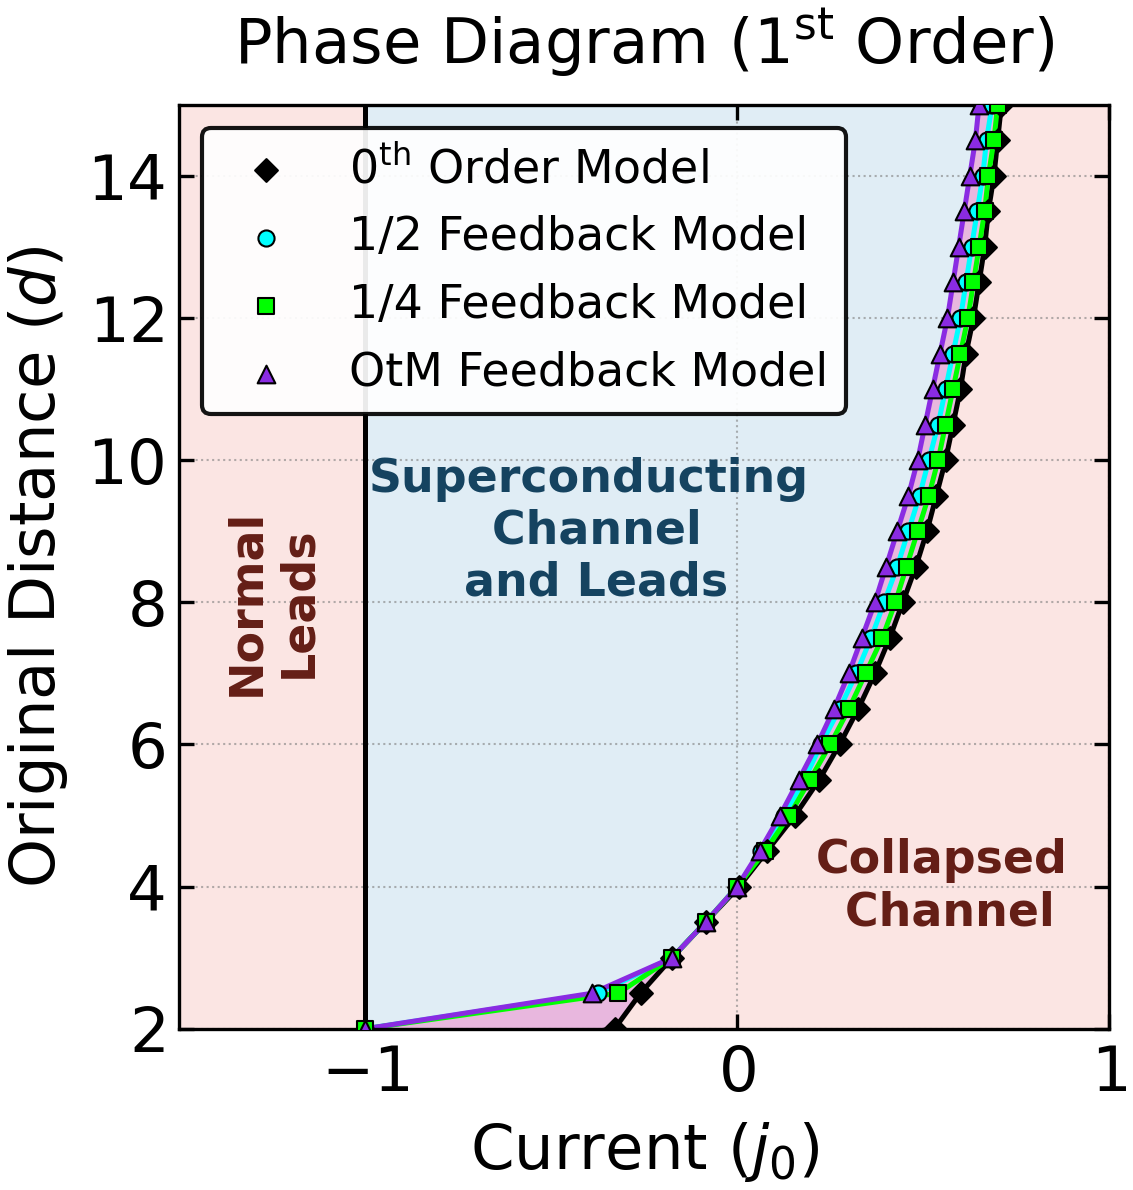

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os

# ================= IMPOSTAZIONI GLOBALI (STILE TESI LATEX) =================
# Width of ONE side-by-side image (~0.48 * 5.5 inches)
fig_width = 2.5  
fig_height = 2.7 # Adjust this to change the aspect ratio

plt.rcParams.update({
    "text.usetex": False,                 
    "mathtext.fontset": "dejavusans",             
    "font.family": "sans-serif",               
    "font.sans-serif": ["DejaVu Sans", "Arial"],
    "axes.formatter.use_mathtext": True,  
    
    # --- The Crucial Sizing Parameters ---
    "figure.figsize": (fig_width, fig_height), 
    "font.size": 15,       
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "legend.fontsize": 12.5,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    # -------------------------------------
    
    "axes.linewidth": 0.8,                
    "lines.linewidth": 1,               
    "xtick.major.width": 0.8,             
    "ytick.major.width": 0.8,             
    "xtick.direction": "in",              
    "ytick.direction": "in",
    "xtick.top": True,                    
    "ytick.right": True,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.framealpha": 0.92,
    "legend.edgecolor": "black",              
    "figure.dpi": 300,                    
    "savefig.bbox": "tight",              
    "savefig.pad_inches": 0.02 
})

# Color used for the "Collapsed Channel" region — reused for "Normal Leads"
collapsed_color = '#fadbd8'
normal_leads_xmin, normal_leads_xmax = -1.5, -1

# ================= DATA LOADING =================
cartella = "."

print("Loading data from multiple files...")
try:
    with open(os.path.join(cartella, "DatiDipoloUnificati1.json"), "r") as f:
        dati_1 = json.load(f)
    with open(os.path.join(cartella, "DatiDipoloUnificati2.json"), "r") as f:
        dati_2 = json.load(f)
    with open(os.path.join(cartella, "DatiDipoloUnificati3.json"), "r") as f:
        dati_3 = json.load(f)
except FileNotFoundError as e:
    print(f"Errore: {e}\nAssicurati che tutti e 3 i file siano nella cartella.")
    dati_1, dati_2, dati_3 = {}, {}, {}

# Estrazione sicura dei punti post-correzione
pts_corr_1 = np.array(dati_1.get("puntiFaseCorr1", []))
pts_corr_2 = np.array(dati_2.get("puntiFaseCorr2", []))
pts_corr_3 = np.array(dati_3.get("puntiFaseCorr3", []))

# Estrazione dei punti del Modello Base (usando il primo dataset)
pts_base = np.array(dati_1.get("puntiFaseBase1", []))

# ================= PLOT UNIFIED PHASE DIAGRAM =================
print("Generating Unified Phase Diagram...")

fig_unified, ax = plt.subplots(figsize=(4.0, 4.0))

# Ordinamento dei punti lungo l'asse y (d) per tracciare le linee correttamente
if len(pts_base) > 0: pts_base = pts_base[pts_base[:, 1].argsort()]
if len(pts_corr_1) > 0: pts_corr_1 = pts_corr_1[pts_corr_1[:, 1].argsort()]
if len(pts_corr_2) > 0: pts_corr_2 = pts_corr_2[pts_corr_2[:, 1].argsort()]
if len(pts_corr_3) > 0: pts_corr_3 = pts_corr_3[pts_corr_3[:, 1].argsort()]

# ================= CREAZIONE DELLE REGIONI COLORATE =================
# Troviamo il range 'y' comune a tutti i dataset per poterli interpolare in sicurezza
y_mins, y_maxs = [], []
for pts in [pts_base, pts_corr_1, pts_corr_2, pts_corr_3]:
    if len(pts) > 0:
        y_mins.append(np.min(pts[:, 1]))
        y_maxs.append(np.max(pts[:, 1]))

if y_mins and y_maxs:
    y_common = np.linspace(max(y_mins), min(y_maxs), 500)
    
    # Calcolo della curva Base interpolata
    x_base_interp = np.interp(y_common, pts_base[:, 1], pts_base[:, 0])
    
    # Calcolo della curva più "a sinistra" (minimum x) tra i modelli del 1° ordine
    x_corrs = []
    if len(pts_corr_1) > 0: x_corrs.append(np.interp(y_common, pts_corr_1[:, 1], pts_corr_1[:, 0]))
    if len(pts_corr_2) > 0: x_corrs.append(np.interp(y_common, pts_corr_2[:, 1], pts_corr_2[:, 0]))
    if len(pts_corr_3) > 0: x_corrs.append(np.interp(y_common, pts_corr_3[:, 1], pts_corr_3[:, 0]))
    
    if x_corrs:
        x_leftmost_corr = np.min(x_corrs, axis=0)
    else:
        x_leftmost_corr = x_base_interp # Fallback se mancano dati
    
    # 0. Regione Normal Leads (Estrema Sinistra, stesso colore di Collapsed Channel)
    ax.fill_betweenx(y_common, normal_leads_xmin, normal_leads_xmax, color=collapsed_color, alpha=0.7, zorder=0)
    ax.axvline(x=normal_leads_xmax, color="black", linewidth=1.2, zorder=3)
    
    # 1. Regione Separata (Sinistra, Azzurro: #d4e6f1)
    ax.fill_betweenx(y_common, -1.0, x_leftmost_corr, color='#d4e6f1', alpha=0.7, zorder=0)
    
    # 2. Regione Mista/Discrepanza (Centro, Viola: #e5dce3 -> media tra #d4e6f1 e #fadbd8)
    ax.fill_betweenx(y_common, x_leftmost_corr, x_base_interp, color="#e3a5d6", alpha=0.8, zorder=0)
    
    # 3. Regione Unita (Destra, Rosso chiaro: #fadbd8)
    ax.fill_betweenx(y_common, x_base_interp, 1.0, color=collapsed_color, alpha=0.7, zorder=0)

# Etichette delle regioni aggiornate
ax.text(-0.40, 9, "Superconducting\n Channel\n and Leads", ha='center', va='center', fontsize=11, fontweight='bold', color='#154360', zorder=4)
ax.text(0.55, 4, "Collapsed\n Channel", ha='center', va='center', fontsize=11, fontweight='bold', color='#641e16', zorder=4)
if y_mins and y_maxs:
    x_mid_leads = (normal_leads_xmin + normal_leads_xmax) / 2
    y_mid_leads = (max(y_mins) + min(y_maxs)) / 2
    ax.text(x_mid_leads, y_mid_leads, "Normal\nLeads", ha='center', va='center', fontsize=11,
            fontweight='bold', color='#641e16', zorder=4, rotation=90)

# ================= PLOT DEI PUNTI =================
# Punti e linee Modello Base (Diamanti Neri)
if len(pts_base) > 0:
    ax.plot(pts_base[:, 0], pts_base[:, 1], color="black", linewidth=1.2, zorder=2)
    ax.scatter(pts_base[:, 0], pts_base[:, 1], 
               color="black", marker="D", s=15, edgecolor="black", linewidth=0.5, 
               label=r"$0^{\mathrm{th}}$ Order Model", zorder=3)

# Punti e linee Modello 1/2 (Cerchi Ciano)
if len(pts_corr_1) > 0:
    ax.plot(pts_corr_1[:, 0], pts_corr_1[:, 1], color="cyan", linewidth=1.2, zorder=2)
    ax.scatter(pts_corr_1[:, 0], pts_corr_1[:, 1], 
               color="cyan", marker="o", s=15, edgecolor="black", linewidth=0.5, 
               label="1/2 Feedback Model", zorder=4)

# Punti e linee Modello 1/4 (Quadrati Lime)
if len(pts_corr_2) > 0:
    ax.plot(pts_corr_2[:, 0], pts_corr_2[:, 1], color="lime", linewidth=1.2, zorder=2)
    ax.scatter(pts_corr_2[:, 0], pts_corr_2[:, 1], 
               color="lime", marker="s", s=15, edgecolor="black", linewidth=0.5, 
               label="1/4 Feedback Model", zorder=5)

# Punti e linee Modello +1 (Triangoli Viola Brillante)
if len(pts_corr_3) > 0:
    ax.plot(pts_corr_3[:, 0], pts_corr_3[:, 1], color="blueviolet", linewidth=1.2, zorder=2)
    ax.scatter(pts_corr_3[:, 0], pts_corr_3[:, 1], 
               color="blueviolet", marker="^", s=18, edgecolor="black", linewidth=0.5, 
               label="OtM Feedback Model", zorder=6)

# Formattazione degli assi
ax.set_xlabel(r"Current ($j_0$)")
ax.set_ylabel(r"Original Distance ($d$)")
ax.set_title(r"Phase Diagram ($1^{\mathrm{st}}$ Order)", pad=10)
ax.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6)
ax.set_xlim(normal_leads_xmin, 1)
ax.set_ylim(2, 15) 

ax.legend(loc="upper left", frameon=True, edgecolor="black", fontsize=11, facecolor="white", framealpha=0.92)

plt.savefig(os.path.join(cartella+"\Grafici\Grafici_Dipolo", "Unified_Phase_Diagram_Feedback.pdf"))
print("Done!")

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# ================= IMPOSTAZIONI GLOBALI (STILE TESI LATEX) =================
fig_width = 2.6  
fig_height = 2.2

plt.rcParams.update({
    "text.usetex": False,                
    "mathtext.fontset": "dejavusans",            
    "font.family": "sans-serif",              
    "font.sans-serif": ["DejaVu Sans", "Arial"],
    "axes.formatter.use_mathtext": True,  
    
    "figure.figsize": (fig_width, fig_height),
    "font.size": 15,      
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "legend.fontsize": 12.5,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    
    "axes.linewidth": 0.8,                
    "lines.linewidth": 1.0,              
    "xtick.major.width": 0.8,            
    "ytick.major.width": 0.8,            
    "xtick.direction": "in",              
    "ytick.direction": "in",
    "xtick.top": True,                    
    "ytick.right": True,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.framealpha": 0.92,
    "legend.edgecolor": "black",              
    "figure.dpi": 300,                    
    "savefig.bbox": "tight",              
    "savefig.pad_inches": 0.02
})

cmap_custom = LinearSegmentedColormap.from_list(
    "BlueToRed",
    ["midnightblue", "dodgerblue", "cyan", "gold", "red", "darkred"]
)
ticks_comuni = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2]

# ================= HELPER FUNCTIONS =================
def draw_obstacles(ax, d_val, label_text="Defects"):
    circle_up = patches.Circle((0, d_val/2), 1.0, edgecolor='black',
                               facecolor=(1.0, 1.0, 1.0, 1),
                               linewidth=1.0, linestyle='-', zorder=4, label=label_text)
    circle_down = patches.Circle((0, -d_val/2), 1.0, edgecolor='black',
                                 facecolor=(1.0, 1.0, 1.0, 1),
                                 linewidth=1.0, linestyle='-', zorder=4)
    ax.add_patch(circle_up)
    ax.add_patch(circle_down)

def plot_segments(ax, segments, style_dict, is_first_label_done):
    for segmento in segments:
        if not segmento:
            continue
        sx = [p[0] for p in segmento]
        sy = [p[1] for p in segmento]
        label = style_dict["label"] if not is_first_label_done else ""
        ax.plot(sx, sy, color=style_dict["color"], linewidth=style_dict["lw"],
                linestyle=style_dict["ls"], zorder=style_dict["zorder"], label=label)
        is_first_label_done = True
    return is_first_label_done

# ================= IMPOSTAZIONE CARTELLE E FILE =================
cartella = "."
cartella_grafici = os.path.join(cartella, "Grafici", "Grafici_Dipolo")
os.makedirs(cartella_grafici, exist_ok=True)

pattern_ricerca = os.path.join(cartella, "linsep*.json")
lista_file_json = glob.glob(pattern_ricerca)

if not lista_file_json:
    print(f"Nessun file JSON trovato nella cartella {cartella}")
else:
    print(f"Trovati {len(lista_file_json)} file JSON da processare.")

# ================= CICLO PRINCIPALE SUI FILE SINGOLI =================
for file_json in lista_file_json:
    
    nome_base = os.path.splitext(os.path.basename(file_json))[0]
    if any(k in nome_base for k in ["corrfor", "corrmed", "corrymin1"]):
        defect_label = r"$1^{\mathrm{st}}$ Order Normal Region"
        crit_label = r"$1^{\mathrm{st}}$ Order Critical Isoline"
    else:
        defect_label = r"$0^{\mathrm{th}}$ Order Normal Region"
        crit_label = r"$0^{\mathrm{th}}$ Order Critical Isoline"
    
    print(f"\n--- Processando (Singolo): {nome_base} ---")
    
    try:
        with open(file_json, "r") as f:
            dati = json.load(f)
    except Exception as e:
        print(f"Errore nella lettura di {file_json}: {e}")
        continue

    curve_data = dati.get("curve", {})
    c_val = dati.get("parametri", {}).get("c", 0.01)
    d_val = dati.get("parametri", {}).get("d", 3.8)

    # FILTRO ARTEFATTO PUNTINO BLU CENTRALE (CORRETTO)
    v_crit_raw = curve_data.get("velocita_critica_v1", [])
    v_crit_filtered = []
    for seg in v_crit_raw:
        if not seg or len(seg) < 3: 
            continue
        
        arr = np.array(seg)
        x_spread = np.max(arr[:, 0]) - np.min(arr[:, 0])
        y_spread = np.max(arr[:, 1]) - np.min(arr[:, 1])
        
        # A real critical isoline has a diameter of ~2.0.
        # The central artifact dot is tiny (close to 0).
        if x_spread > 0.5 or y_spread > 0.5:
            v_crit_filtered.append(seg)
            
    curve_data["velocita_critica_v1"] = v_crit_filtered

    # GRIGLIA 2D
    lim_y = d_val/2 + 3
    x = np.linspace(-4, 4, 500)
    y = np.linspace(-lim_y, lim_y, 500)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    Z_up = Z - 1j * (d_val / 2)
    Z_down = Z + 1j * (d_val / 2)

    W = 1j * c_val * (Z + 1/Z_up + 1/Z_down) + np.log(Z_up + 1e-12) - np.log(Z_down + 1e-12)
    dW = 1j * c_val * (1 - 1/Z_up**2 - 1/Z_down**2) + 1/Z_up - 1/Z_down

    wIm = np.imag(W)
    U = np.imag(dW)
    V = np.real(dW)
    vel = np.abs(dW)

    style_critica = {"color": "#0400FF", "lw": 1.6, "ls": "--", "zorder": 5, "label": crit_label}
    
    # --- GRAFICO 1 ---
    fig1, ax1 = plt.subplots(figsize=(6.8, 6.0))
    draw_obstacles(ax1, d_val, defect_label)
    style_flusso = {"color": "deeppink", "lw": 1.0, "ls": "--", "zorder": 2, "label": r"Streamlines"}
    style_pot = {"color": "dodgerblue", "lw": 1.0, "ls": "--", "zorder": 2, "label": r"Isolines of $\theta(r)$"}
    plot_segments(ax1, curve_data.get("linee_flusso_Re", []), style_flusso, False)
    plot_segments(ax1, curve_data.get("linee_potenziale_Im", []), style_pot, False)
    plot_segments(ax1, curve_data.get("velocita_critica_v1", []), style_critica, False)
    ax1.set(xlim=(-4, 4), ylim=(-lim_y, lim_y), aspect='equal', xlabel=r"$x$", ylabel=r"$y$", title="Streamlines and Isolines")
    
    transparent_cmap = LinearSegmentedColormap.from_list("transparent", [(0,0,0,0), (0,0,0,0)])
    sm_fake = plt.cm.ScalarMappable(cmap=transparent_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm_fake.set_array([])
    cbar_fake = fig1.colorbar(sm_fake, ax=ax1, fraction=0.046, pad=0.04)
    cbar_fake.set_ticks([]) 
    cbar_fake.outline.set_visible(False)

    # --- Legenda divisa in due gruppi ---
    # Gruppo A: elementi che contengono "Order" (Normal Region / Critical Isoline) -> in basso a sinistra
    # Gruppo B: tutto il resto (Streamlines, Isolines) -> in alto a sinistra
    handles1, labels1 = ax1.get_legend_handles_labels()
    order_keywords = ["Order Normal Region", "Order Critical Isoline"]
    handles_order = [h for h, l in zip(handles1, labels1) if any(k in l for k in order_keywords)]
    labels_order = [l for l in labels1 if any(k in l for k in order_keywords)]
    handles_other = [h for h, l in zip(handles1, labels1) if not any(k in l for k in order_keywords)]
    labels_other = [l for l in labels1 if not any(k in l for k in order_keywords)]

    if np.isclose(c_val, -0.5, atol=1e-6):
        # For c=-0.5, merge both groups into a single legend positioned "center left"
        # (keeping them split here would overlap at the same anchor point).
        combined_handles = handles_order + handles_other
        combined_labels = labels_order + labels_other
        if combined_handles:
            ax1.legend(combined_handles, combined_labels, loc="center left", frameon=True,
                       edgecolor="black", facecolor="white", framealpha=0.92, fontsize=10)
    else:
        if handles_order:
            legend_order = ax1.legend(handles_order, labels_order, loc="lower left", frameon=True,
                                       edgecolor="black", facecolor="white", framealpha=0.92, fontsize=10)
            ax1.add_artist(legend_order)  # necessario per non perdere questa legenda quando si chiama legend() di nuovo
        if handles_other:
            ax1.legend(handles_other, labels_other, loc="upper left", frameon=True,
                       edgecolor="black", facecolor="white", framealpha=0.92, fontsize=10)

    fig1.savefig(os.path.join(cartella_grafici, f"1_FlussoPotenziale_{nome_base}.pdf"), dpi=300, bbox_inches="tight")

    '''# --- GRAFICO 2 ---
    fig2, ax2 = plt.subplots(figsize=(7.5, 6.0))
    draw_obstacles(ax2, d_val, defect_label)
    fase = ((wIm / np.pi) + 1) / 2 % 1
    mappa_fase = ax2.pcolormesh(X, Y, fase, cmap='hsv', shading='auto', zorder=1)
    cbar_fase = fig2.colorbar(mappa_fase, ax=ax2, fraction=0.046, pad=0.04)
    cbar_fase.set_label(r'Phase (mod $\pi$)')
    plot_segments(ax2, curve_data.get("velocita_critica_v1", []), style_critica, False)
    ax2.set(xlim=(-4, 4), ylim=(-lim_y-0.05, lim_y+0.05), aspect='equal', xlabel=r"$x$", ylabel=r"$y$", title=r"Phase ($\theta$)")
    ax2.legend(loc="upper left", frameon=True, edgecolor="black", facecolor="white", framealpha=0.92, fontsize=10.5)
    fig2.savefig(os.path.join(cartella_grafici, f"2_FaseImmaginaria_{nome_base}.pdf"), dpi=300, bbox_inches="tight")'''
    
    # --- GRAFICO 3 ---
    fig3, ax3 = plt.subplots(figsize=(7.5, 6.0))
    draw_obstacles(ax3, d_val, defect_label)
    skip = 22
    X_q, Y_q = X[::skip, ::skip], Y[::skip, ::skip]
    U_q, V_q, vel_q = U[::skip, ::skip], V[::skip, ::skip], vel[::skip, ::skip]
    vel_safe = np.where(vel_q == 0, 1e-12, vel_q)
    U_norm, V_norm = U_q / vel_safe, V_q / vel_safe
    vel_color = np.clip(vel_q, 0, 1.2)
    Q = ax3.quiver(X_q, Y_q, U_norm, V_norm, vel_color, cmap=cmap_custom, alpha=0.9, zorder=2, pivot='mid',
                   scale=22, width=0.004, headwidth=2.8, headlength=3.5, headaxislength=3.0)
    Q.set_clim(0, 1.2)
    cbar_quiver = fig3.colorbar(Q, ax=ax3, fraction=0.046, pad=0.04, extend='max', ticks=ticks_comuni)
    cbar_quiver.set_label(r'Velocity Magnitude $|\nabla \theta|$')
    plot_segments(ax3, curve_data.get("velocita_critica_v1", []), style_critica, False)
    ax3.set(xlim=(-4, 4), ylim=(-lim_y, lim_y), aspect='equal', xlabel=r"$x$", ylabel=r"$y$", title=r"Current Velocity Field ($\nabla \theta$)")
    ax3.legend(loc="upper left", frameon=True, edgecolor="black", facecolor="white", framealpha=0.92, fontsize=10.5)
    fig3.savefig(os.path.join(cartella_grafici, f"3_Gradiente_{nome_base}.pdf"), dpi=300, bbox_inches="tight")

    # --- GRAFICO 4 (Singolo) ---
    fig4, ax4 = plt.subplots(figsize=(6.0, 4.0))
    style_bordo = {"color": "dodgerblue", "lw": 1.0, "ls": "-", "zorder": 3, "label": r"Normal Region Surface Velocity $|v(\theta)|$"}
    plot_segments(ax4, curve_data.get("velocita_bordo_theta", []), style_bordo, False)
    ax4.axhline(1.0, color='deeppink', linestyle=':', linewidth=1.0, zorder=2, label="Critical Threshold ($|v|=1$)")
    ax4.set_xlim(0, 2 * np.pi)
    ax4.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax4.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax4.set(xlabel=r"Polar Angle ($\theta$)", ylabel=r"Velocity Magnitude ($|v|$)", title="Velocity Profile along the Optimized Core")
    ax4.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6)
    ax4.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", fontsize=12.0)
    fig4.savefig(os.path.join(cartella_grafici, f"4_VelocitaBordo_{nome_base}.pdf"), dpi=300, bbox_inches="tight")

    '''# --- GRAFICO 5 ---
    fig5, ax5 = plt.subplots(figsize=(7.5, 6.0))
    draw_obstacles(ax5, d_val, defect_label)
    livelli = np.linspace(0, 1.2, 30)
    mappa_vel = ax5.contourf(X, Y, vel, levels=livelli, cmap=cmap_custom, extend='max', zorder=1, alpha=0.9)
    ax5.contour(X, Y, vel, levels=livelli, colors='white', linewidths=0.5, alpha=0.3, zorder=2)
    cbar_vel = fig5.colorbar(mappa_vel, ax=ax5, fraction=0.046, pad=0.04, extend='max', ticks=ticks_comuni)
    cbar_vel.set_label(r'Velocity Magnitude $|\mathbf{v}|$')
    plot_segments(ax5, curve_data.get("velocita_critica_v1", []), style_critica, False)
    ax5.set(xlim=(-4, 4), ylim=(-lim_y, lim_y), aspect='equal', xlabel=r"$x$", ylabel=r"$y$", title="Velocity Field Magnitude & Critical Boundaries")
    ax5.legend(loc="upper left", frameon=True, edgecolor="black", facecolor="white", framealpha=0.92, fontsize=10.5)
    fig5.savefig(os.path.join(cartella_grafici, f"5_MappaVelocita_{nome_base}.pdf"), dpi=300, bbox_inches="tight") '''

    plt.close('all')


# ================= CONFRONTO VELOCITÀ SUL BORDO (DINAMICO) =================
print("\nGenerating combined boundary velocity plots...")

def crea_confronto_bordo(modelli_dict, file_out_name, titolo, c_val_str):
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    
    stili = {
        r"$0^{\mathrm{th}}$ Order Model": {"color": "black", "ls": "--", "lw": 1.2},
        "1/2 Feedback Model": {"color": "dodgerblue", "ls": "-", "lw": 1.2},
        "1/4 Feedback Model": {"color": "forestgreen", "ls": "-.", "lw": 1.2},
        "OtM Feedback Model": {"color": "darkorange", "ls": ":", "lw": 1.5}
    }
    
    ordine_desiderato = [
        r"$0^{\mathrm{th}}$ Order Model",
        "1/2 Feedback Model",
        "1/4 Feedback Model",
        "OtM Feedback Model"
    ]
    
    for label_mod in ordine_desiderato:
        if label_mod in modelli_dict:
            fpath = modelli_dict[label_mod]
            if os.path.exists(fpath):
                with open(fpath, "r") as f:
                    d = json.load(f)
                
                segmenti = d.get("curve", {}).get("velocita_bordo_theta", [])
                
                is_first = True
                for seg in segmenti:
                    if not seg: 
                        continue
                    sx = [p[0] for p in seg]
                    sy = [p[1] for p in seg]
                    
                    label_to_use = label_mod if is_first else ""
                    st = stili[label_mod]
                    ax.plot(sx, sy, color=st["color"], linestyle=st["ls"], linewidth=st["lw"], label=label_to_use)
                    is_first = False

    ax.axhline(1.0, color='deeppink', linestyle=':', linewidth=1.0, zorder=2, label="Critical Threshold ($|v|=1$)")
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set(xlabel=r"Polar Angle ($\theta$)", ylabel=r"Velocity Magnitude ($|v|$)", title=titolo)
    ax.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6)
    
    # Custom legend positioning logic based on c
    if c_val_str == "-0.1":
        legend_loc = "upper left"
    elif c_val_str == "-0.5":
        legend_loc = "upper right"
    elif c_val_str == "0.1":
        legend_loc = "lower left"
    elif c_val_str == "0.4":
        legend_loc = "upper left"
    elif c_val_str == "0.5":
        legend_loc = "upper right"
    else:
        # Default positioning if a different current value appears
        legend_loc = "upper right" 
        
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, loc=legend_loc, frameon=True, facecolor="white", framealpha=0.92, edgecolor="black", fontsize=10.5)
        
    fig.savefig(os.path.join(cartella_grafici, file_out_name), dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved {file_out_name} with legend at {legend_loc}")


# Estrazione e raggruppamento rigoroso dei file
gruppi_c = {}
for file_json in lista_file_json:
    nome_base = os.path.splitext(os.path.basename(file_json))[0]
    
    match_c = re.search(r'c(-?\d+\.\d+)', nome_base)
    
    if match_c:
        c_str = match_c.group(1)
        if c_str not in gruppi_c:
            gruppi_c[c_str] = {}
            
        if "nocorr" in nome_base:
            gruppi_c[c_str][r"$0^{\mathrm{th}}$ Order Model"] = file_json
        elif "corrfor" in nome_base:
            gruppi_c[c_str]["1/2 Feedback Model"] = file_json
        elif "corrmed" in nome_base:
            gruppi_c[c_str]["1/4 Feedback Model"] = file_json
        elif "corrymin1" in nome_base:
            gruppi_c[c_str]["OtM Feedback Model"] = file_json

# Generazione dei plot uniti per ogni gruppo di 'c'
for c_val_str, modelli in gruppi_c.items():
    if len(modelli) > 1: 
        nome_out = f"4_VelocitaBordo_confronto_c{c_val_str}.pdf"
        titolo_grafico = f"Boundary Surface Velocity Comparison ($c={c_val_str}$)"
        crea_confronto_bordo(modelli, nome_out, titolo_grafico, c_val_str)

print("\nTutti i processi sono stati completati con successo!")

<>:196: SyntaxWarning: invalid escape sequence '\p'
<>:240: SyntaxWarning: invalid escape sequence '\m'
<>:196: SyntaxWarning: invalid escape sequence '\p'
<>:240: SyntaxWarning: invalid escape sequence '\m'
C:\Users\franc\AppData\Local\Temp\ipykernel_21284\77344204.py:196: SyntaxWarning: invalid escape sequence '\p'
  '''# --- GRAFICO 2 ---
C:\Users\franc\AppData\Local\Temp\ipykernel_21284\77344204.py:240: SyntaxWarning: invalid escape sequence '\m'
  '''# --- GRAFICO 5 ---


Trovati 15 file JSON da processare.

--- Processando (Singolo): linsep_corrfor_c-0.5_dati ---

--- Processando (Singolo): linsep_corrfor_c0.1_dati ---

--- Processando (Singolo): linsep_corrfor_c0.4_dati ---

--- Processando (Singolo): linsep_corrmed_c-0.5_dati ---

--- Processando (Singolo): linsep_corrmed_c0.1_dati ---

--- Processando (Singolo): linsep_corrmed_c0.4_dati ---

--- Processando (Singolo): linsep_corrmed_c0.5_dati ---

--- Processando (Singolo): linsep_corrymin1_c-0.5_dati ---

--- Processando (Singolo): linsep_corrymin1_c0.1_dati ---

--- Processando (Singolo): linsep_corrymin1_c0.4_dati ---

--- Processando (Singolo): linsep_nocorr_c-0.5_dati ---

--- Processando (Singolo): linsep_nocorr_c0.1_dati ---

--- Processando (Singolo): linsep_nocorr_c0.4_dati ---

--- Processando (Singolo): linsep_nocorr_c0.5_dati ---

--- Processando (Singolo): linsep_nocorr_c0_dati ---

Generating combined boundary velocity plots...
Saved 4_VelocitaBordo_confronto_c-0.5.pdf with legend at u